# BREAST CANCER PREDICTION BY USING LOGISTIC REGRESSION

## DATA COLLECTION

#### _The Breast Cancer Wisconsin Dataset is obtained from Kaggle. The target variable is diagnosis, a categorical variable with two classes: Benign (B) and Malignant (M). The goal of this project is to predict whether a tumor is benign or malignant using Logistic Regression based on the selected numerical features._

### Import Required Libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.metrics import confusion_matrix
import warnings
warnings.filterwarnings('ignore')

## LOAD AND READ THE DATASET

In [2]:
df =pd.read_csv('data.csv')
df

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,...,17.33,184.60,2019.0,0.16220,0.66560,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,...,23.41,158.80,1956.0,0.12380,0.18660,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,...,25.53,152.50,1709.0,0.14440,0.42450,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,...,26.50,98.87,567.7,0.20980,0.86630,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,...,16.67,152.20,1575.0,0.13740,0.20500,0.4000,0.1625,0.2364,0.07678,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN


### DATA UNDERSTANDING

#### _Data understanding is performed to analyze the structure of the dataset, including the number of rows and columns, data types, summary statistics, column names, and missing values. This helps in identifying the characteristics of the dataset before preprocessing and model building._

In [3]:
df.shape

(569, 33)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [5]:
df.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [6]:
df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [7]:
df.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [8]:
df.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [9]:
df.isnull().sum()

id                           0
diagnosis                    0
radius_mean                  0
texture_mean                 0
perimeter_mean               0
area_mean                    0
smoothness_mean              0
compactness_mean             0
concavity_mean               0
concave points_mean          0
symmetry_mean                0
fractal_dimension_mean       0
radius_se                    0
texture_se                   0
perimeter_se                 0
area_se                      0
smoothness_se                0
compactness_se               0
concavity_se                 0
concave points_se            0
symmetry_se                  0
fractal_dimension_se         0
radius_worst                 0
texture_worst                0
perimeter_worst              0
area_worst                   0
smoothness_worst             0
compactness_worst            0
concavity_worst              0
concave points_worst         0
symmetry_worst               0
fractal_dimension_worst      0
Unnamed:

In [10]:
df.duplicated().sum()

np.int64(0)

## EXPLORATORY DATA ANALYSIS (EDA)

#### _Exploratory Data Analysis (EDA) is performed to understand the distribution of variables, detect outliers, identify patterns, and analyze relationships between features using statistical summaries and visualizations._

### HISTOGRAM

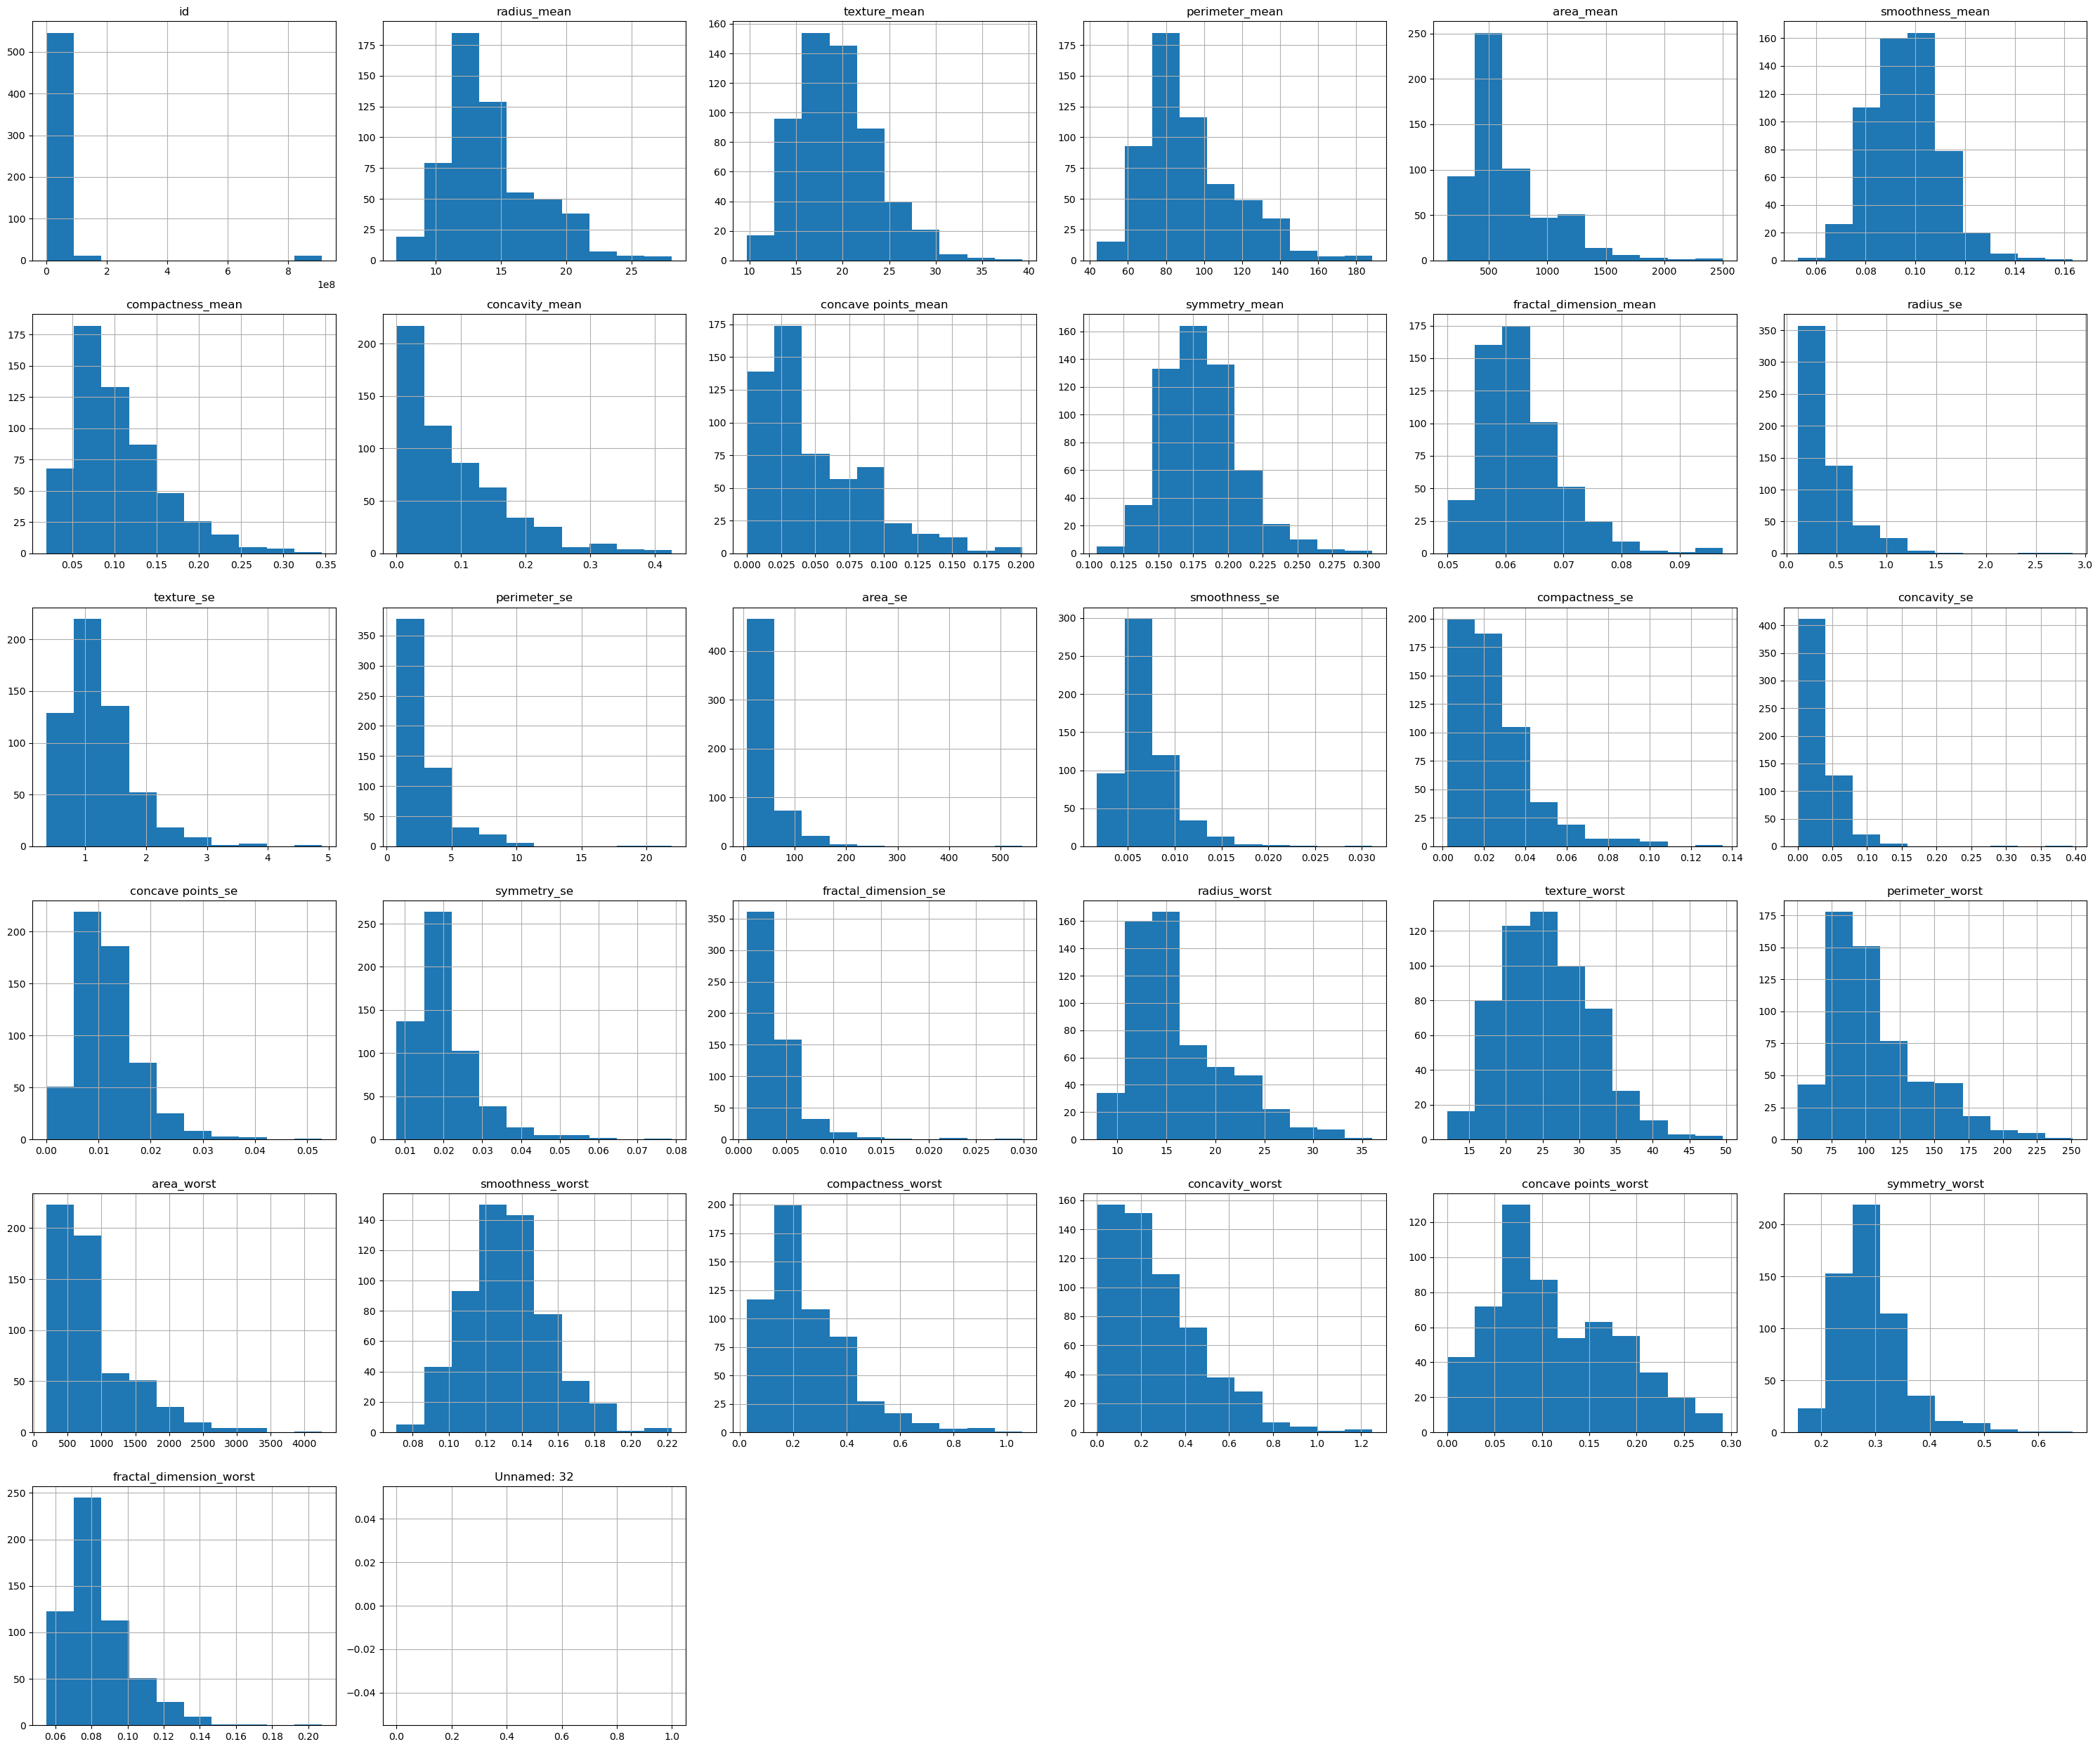

In [11]:
df.hist(figsize = (30,25))
plt.tight_layout()
plt.show()

#### _The histograms show that features such as area_mean, area_worst, radius_mean, radius_worst, perimeter_mean, and perimeter_worst are positively skewed, while a few features are approximately normally distributed. Some features also exhibit extreme values, indicating potential outliers._

## SCATTERPLOT

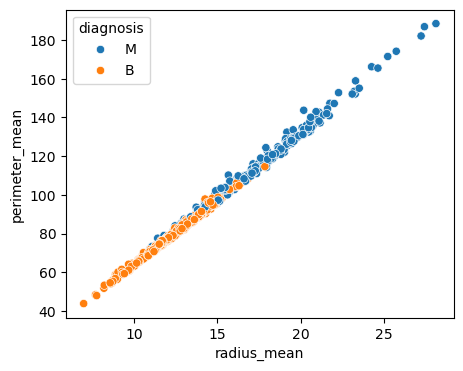

In [12]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='radius_mean',
    y='perimeter_mean',
    hue='diagnosis',
    
)
plt.show()

#### _The scatter plot shows a strong positive relationship between radius_mean and perimeter_mean. As the mean radius increases, the mean perimeter also increases. The Benign (B) and Malignant (M) cases form distinct clusters, indicating that these features are useful for classification._

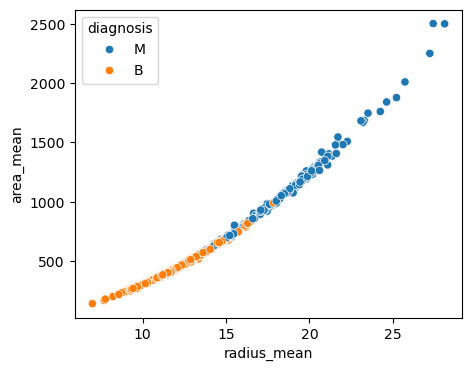

In [13]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='radius_mean',
    y='area_mean',
    hue='diagnosis',
)
plt.show()

#### _The scatter plot indicates a strong positive correlation between radius_mean and area_mean. Malignant tumors tend to have larger radius and area values than Benign tumors, resulting in a clear separation between the two classes._

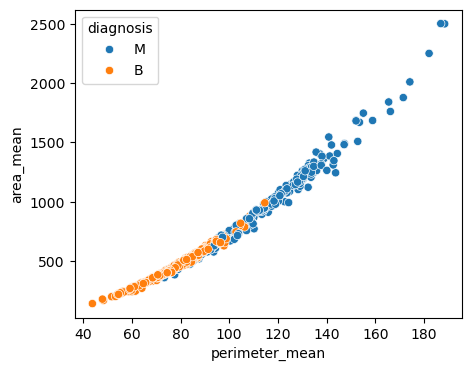

In [14]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='perimeter_mean',
    y='area_mean',
    hue='diagnosis',
)
plt.show()

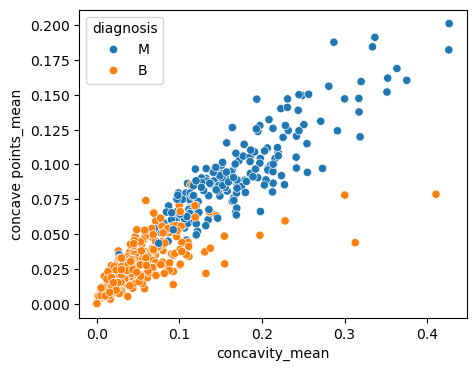

In [15]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='concavity_mean',
    y='concave points_mean',
    hue='diagnosis',
)
plt.show()

#### _The scatter plot indicates a strong positive correlation between concavity_mean and concave points_mean. Malignant tumors tend to have higher concavity and concave point values than Benign tumors, making these features useful for classification._

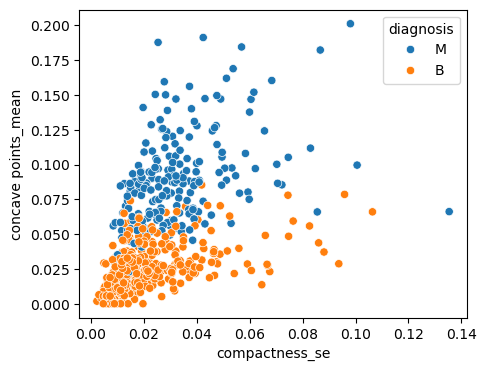

In [16]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='compactness_se',
    y='concave points_mean',
    hue='diagnosis',
)
plt.show()

#### _The scatter plot shows a positive relationship between compactness_se and concave points_mean. Malignant tumors generally have higher values than benign tumors, making these features useful for classification._

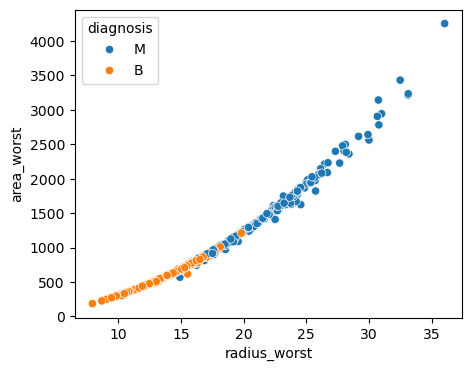

In [17]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='radius_worst',
    y='area_worst',
    hue='diagnosis',
)
plt.show()

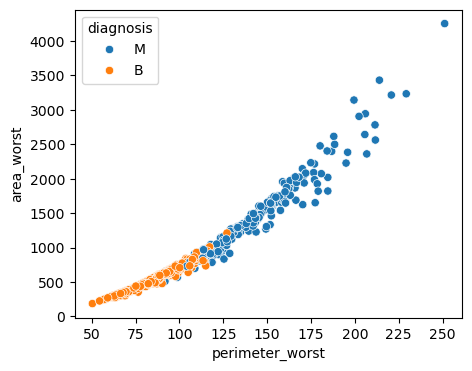

In [18]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='perimeter_worst',
    y='area_worst',
    hue='diagnosis',
)
plt.show()

## COUNT PLOT

#### _A count plot is used to visualize the distribution of the categorical diagnosis variable and assess the frequency of each class._

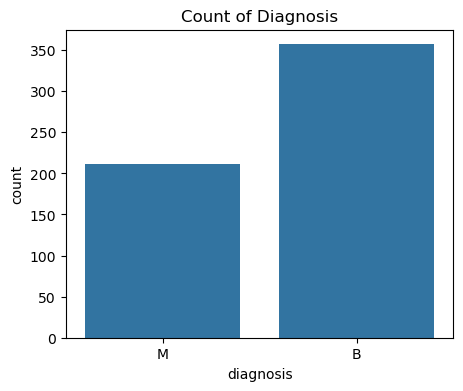

In [19]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='diagnosis')
plt.title('Count of Diagnosis')
plt.show()

#### _The plot shows that Benign (B) cases are more frequent than Malignant (M) cases, indicating a slight class imbalance in the dataset._

## BOXPLOT

#### _The box plots indicate the presence of outliers in several numerical features. These outliers may affect model performance and should be handled during data preprocessing._

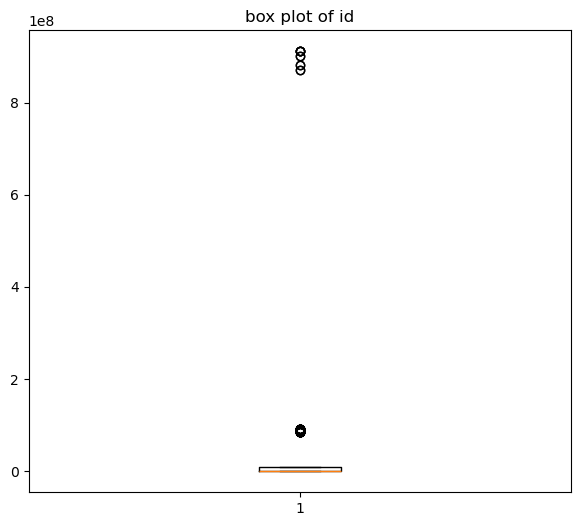

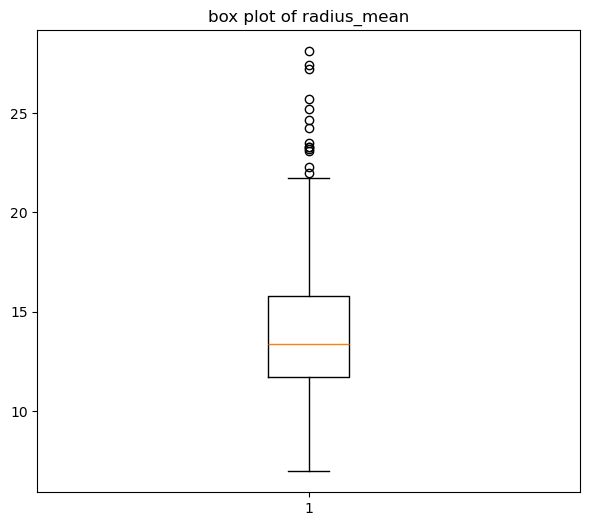

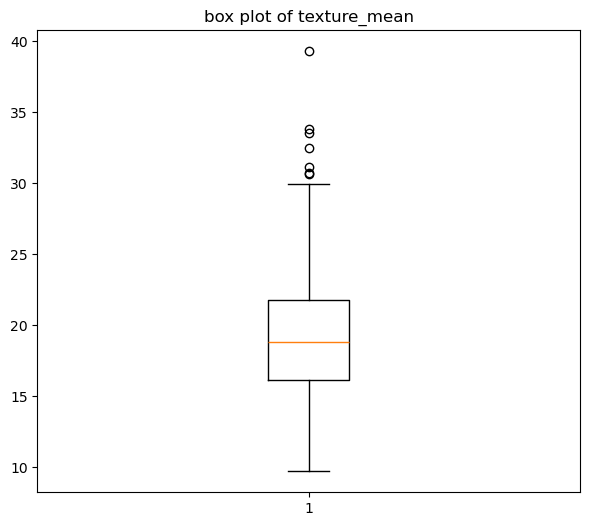

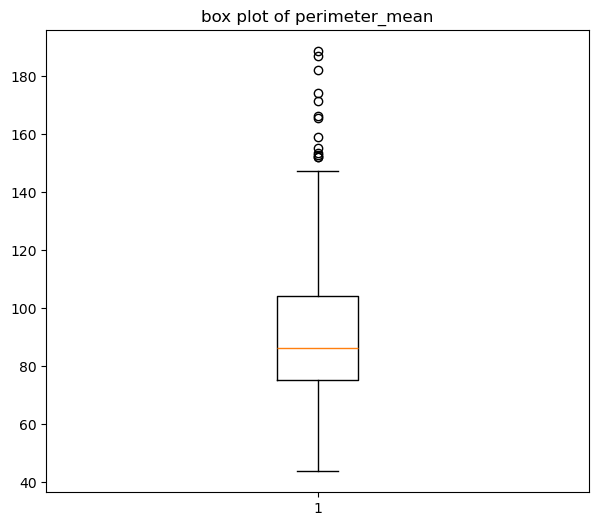

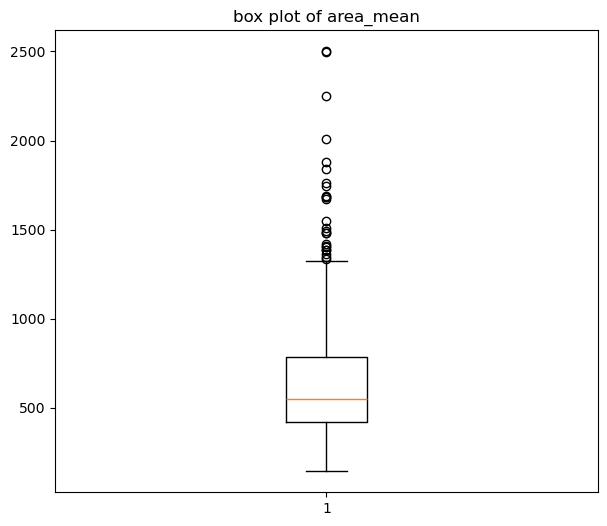

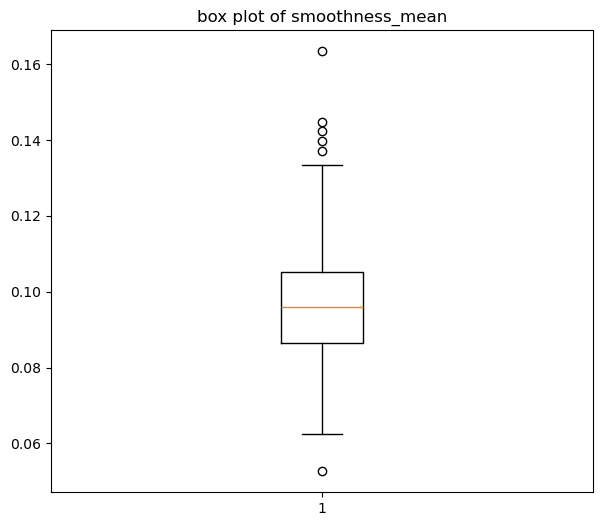

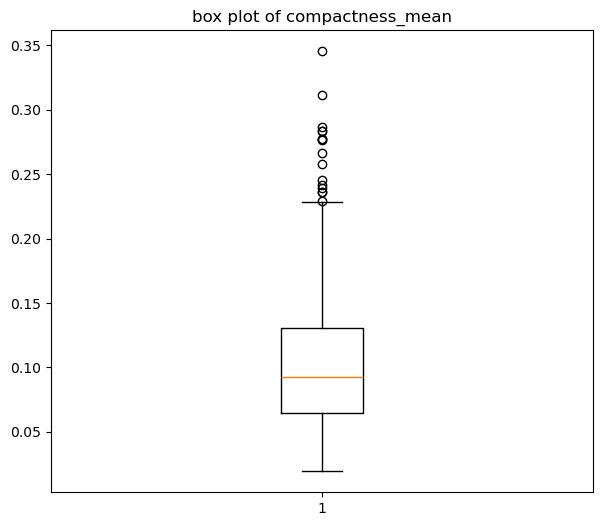

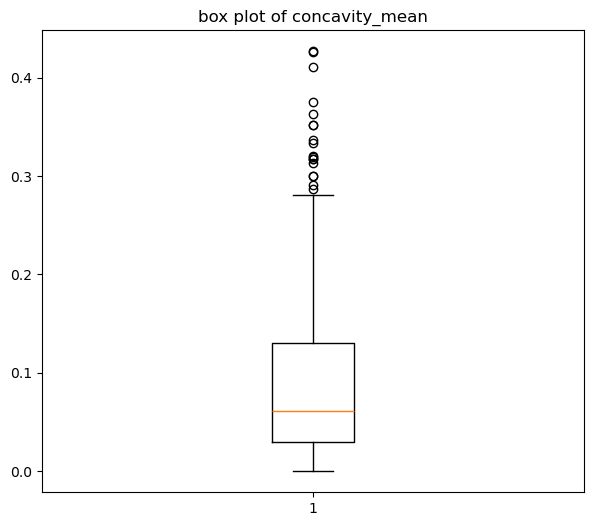

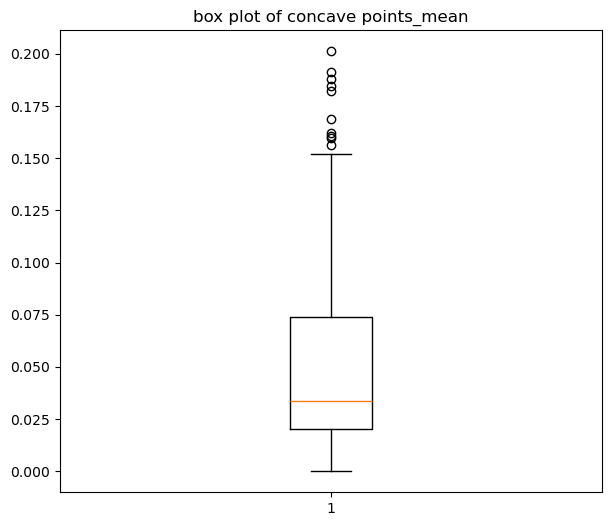

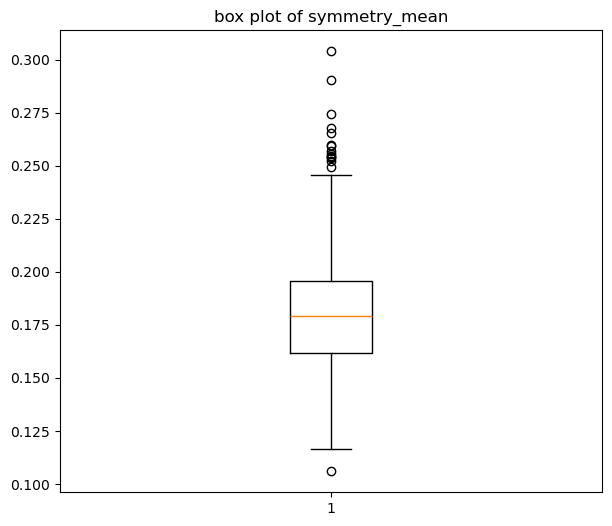

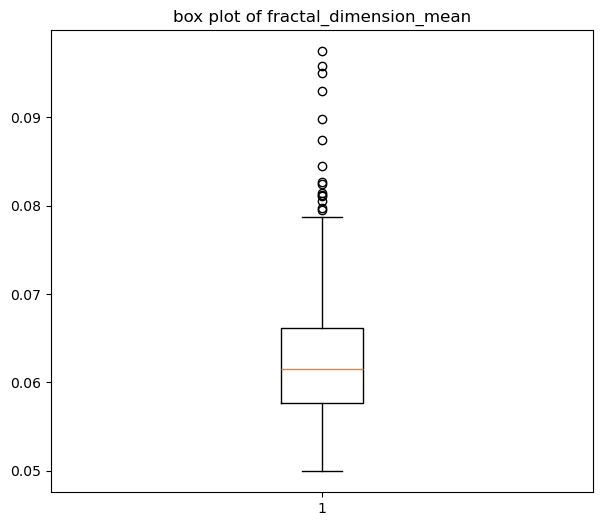

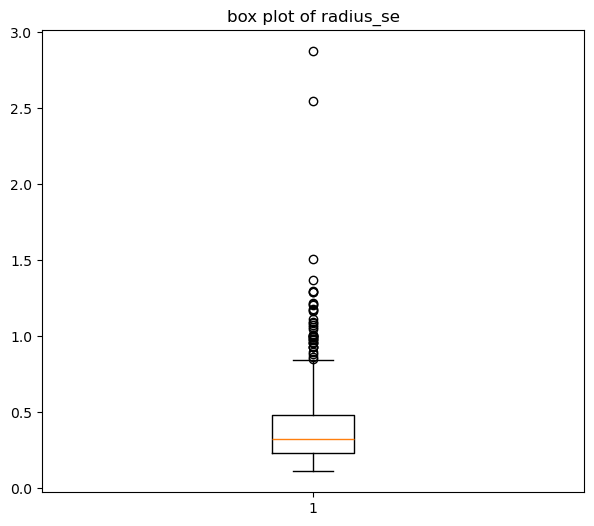

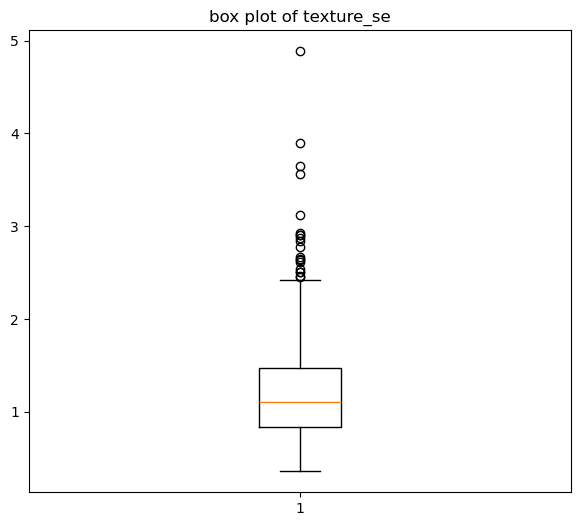

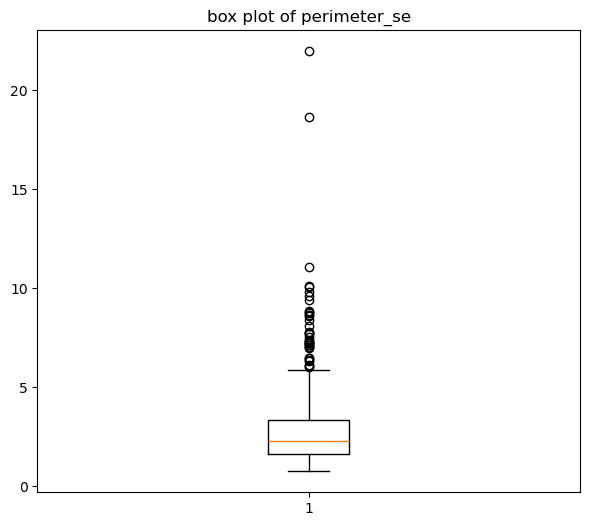

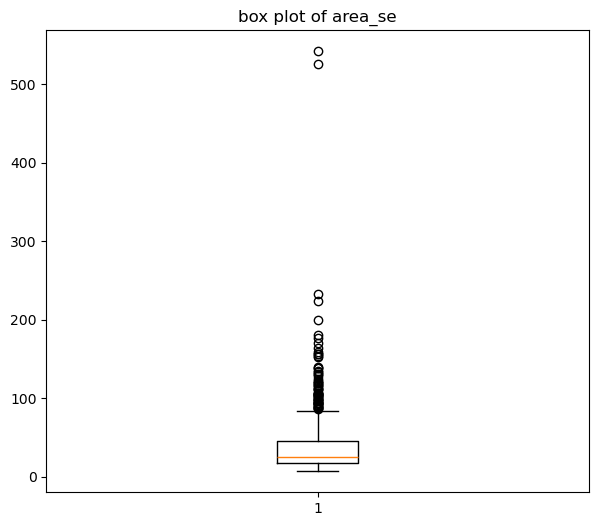

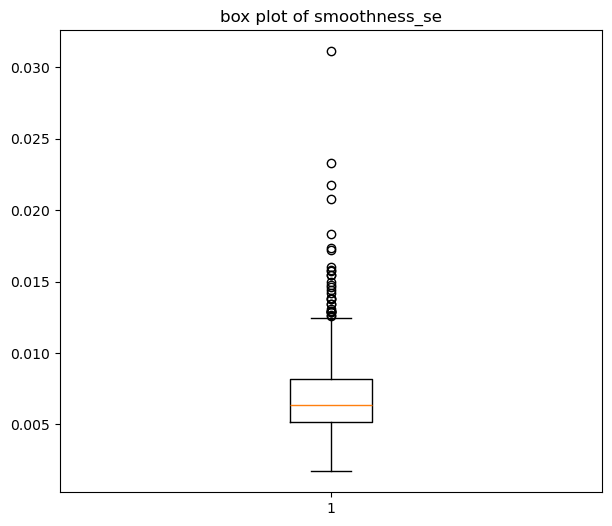

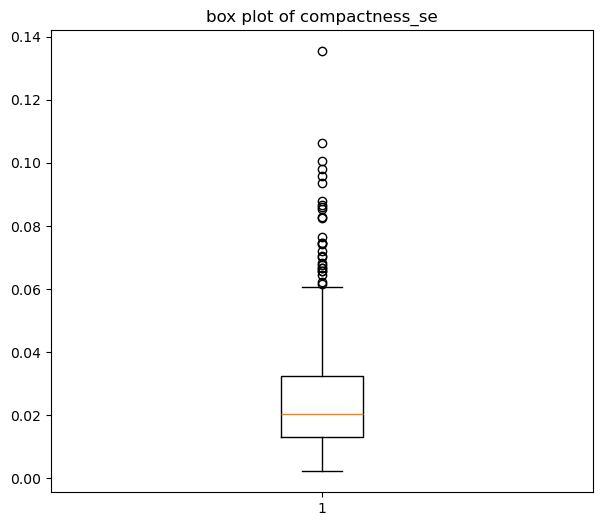

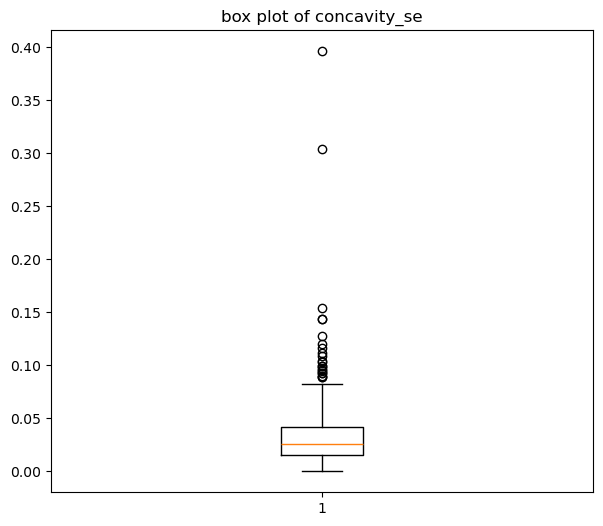

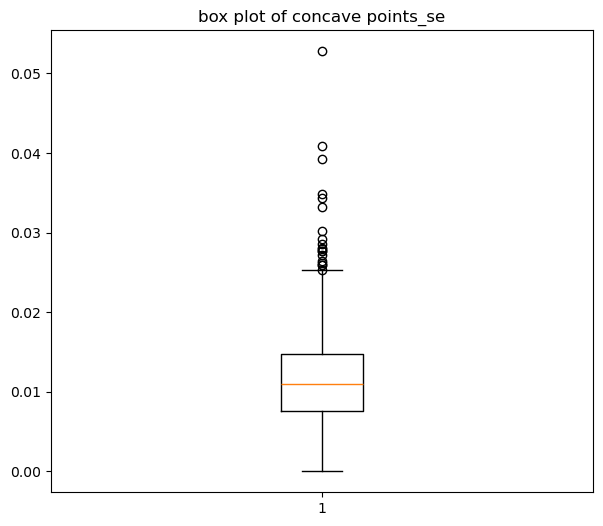

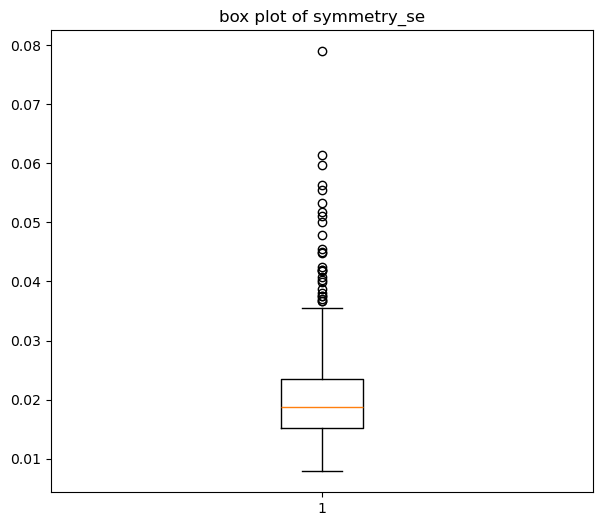

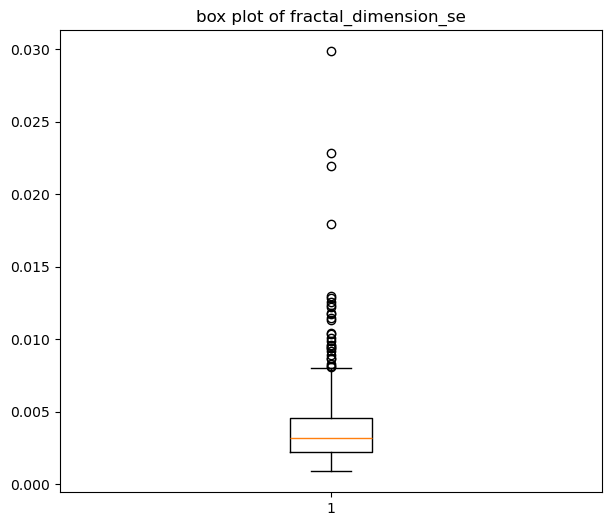

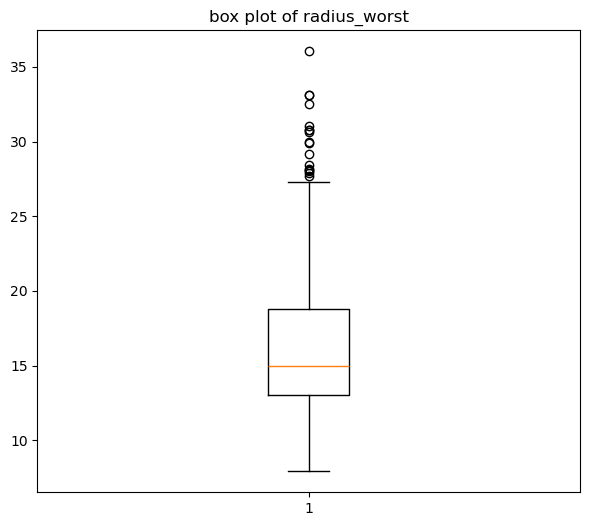

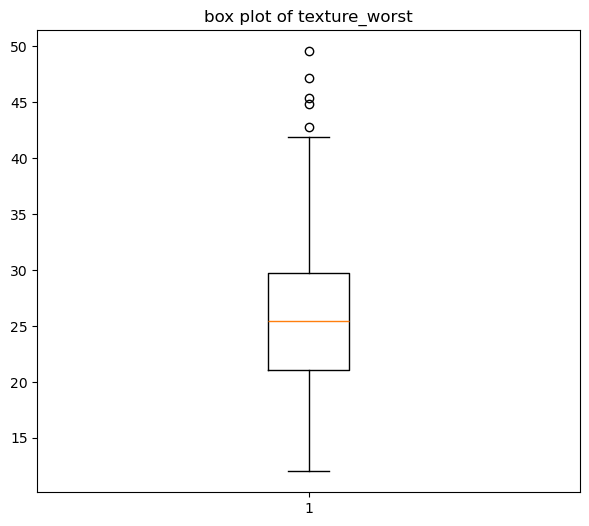

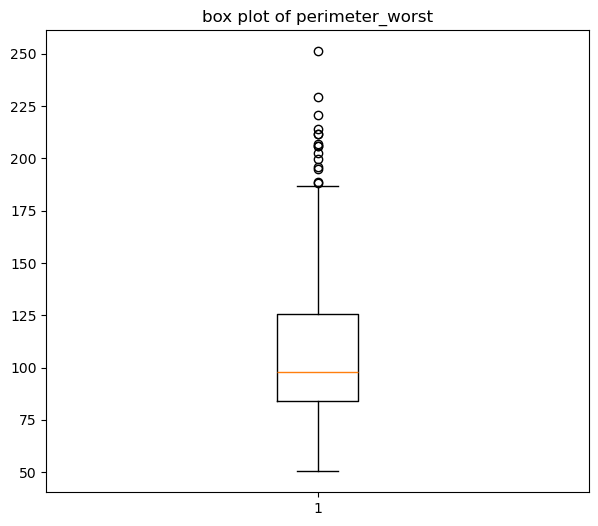

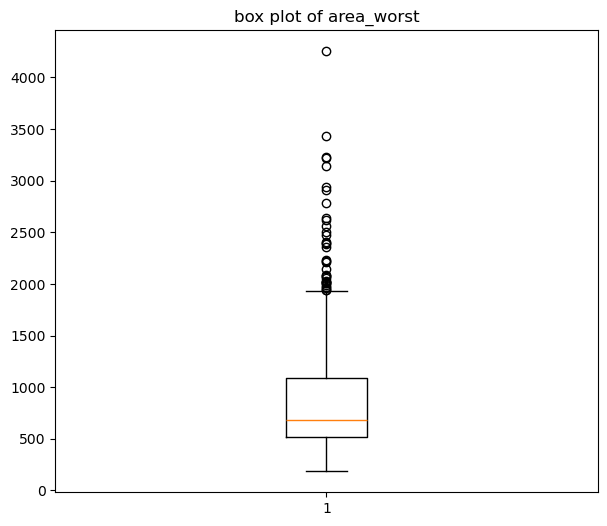

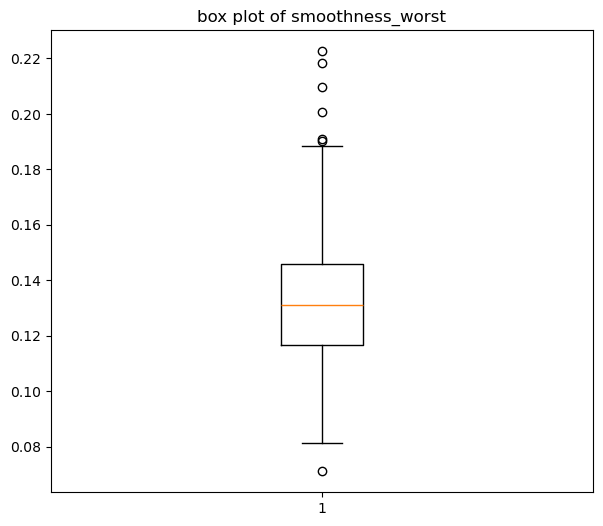

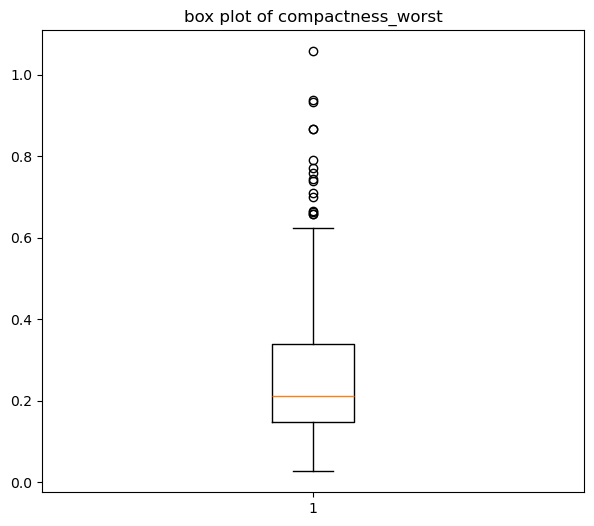

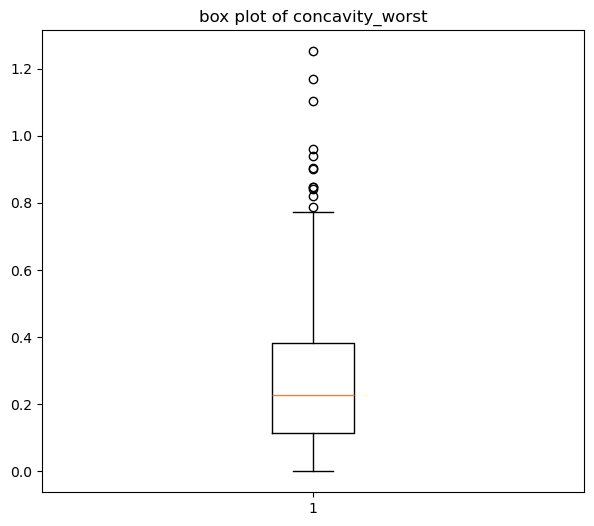

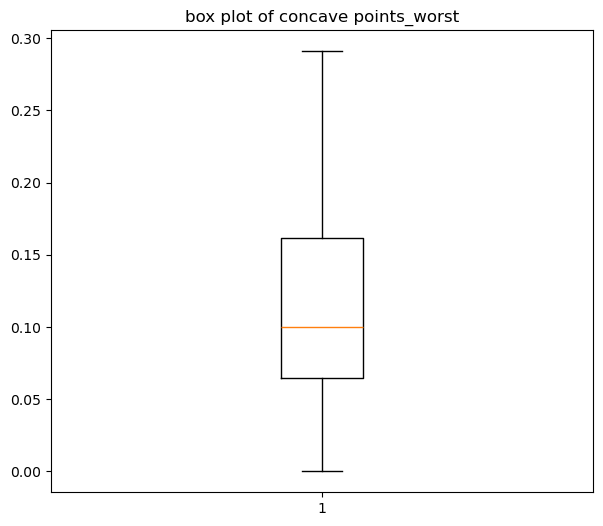

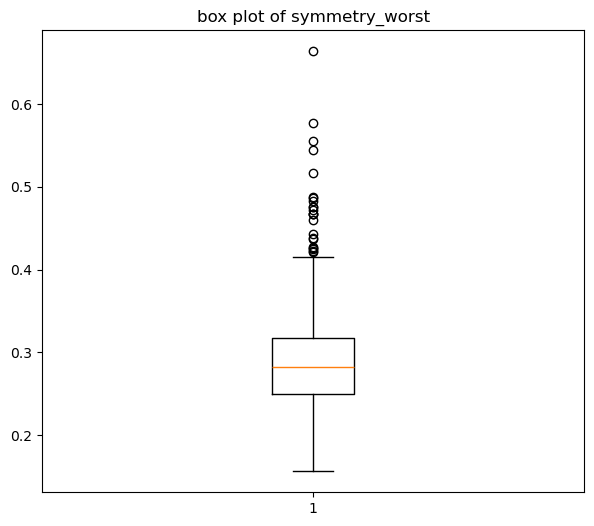

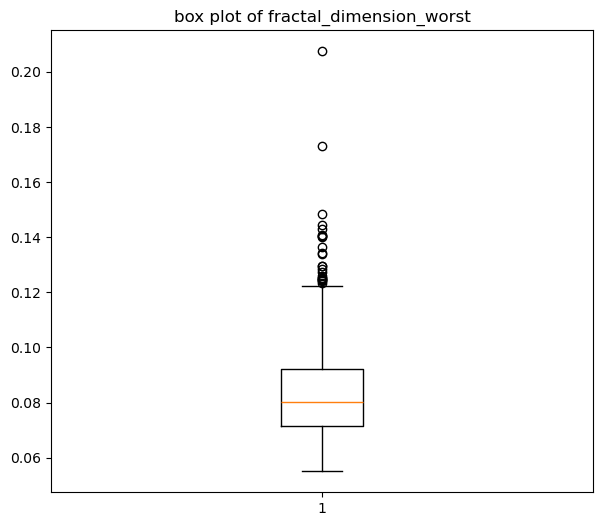

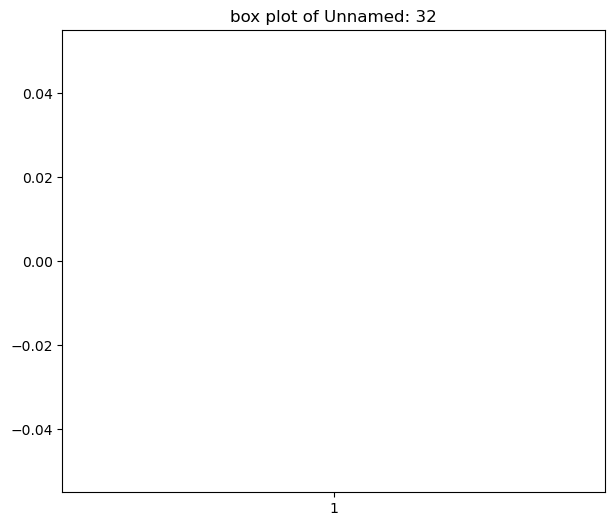

In [20]:
num_cols = df.select_dtypes(include='number').columns
for i in num_cols:
    plt.figure(figsize=(7,6))
    plt.title(f"box plot of {i}")
    plt.boxplot(df[i])
    plt.show()

## DATA CLEANING

#### REMOVING UNWANTED COLUMNS

#### _The id column is only a unique identifier and does not contribute to prediction, while Unnamed: 32 contains only missing values. Therefore, both columns are removed._

In [21]:
df = df.drop(['id','Unnamed: 32'], axis = 1)

#### NO NULL VALUES

#### NO DUPLICATE ROWS

## HANDLING OUTLIERS

#### _Outliers are treated using the IQR method with clipping to reduce the impact of extreme values while preserving all observations._

In [22]:
num_cols = df.select_dtypes(include='number').columns

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df[col] = df[col].clip(lower=lower, upper=upper)

#### _Outliers have been capped within the IQR limits, reducing their influence on the dataset and improving its suitability for analysis and model training._

## EDA AFTER CLEANING

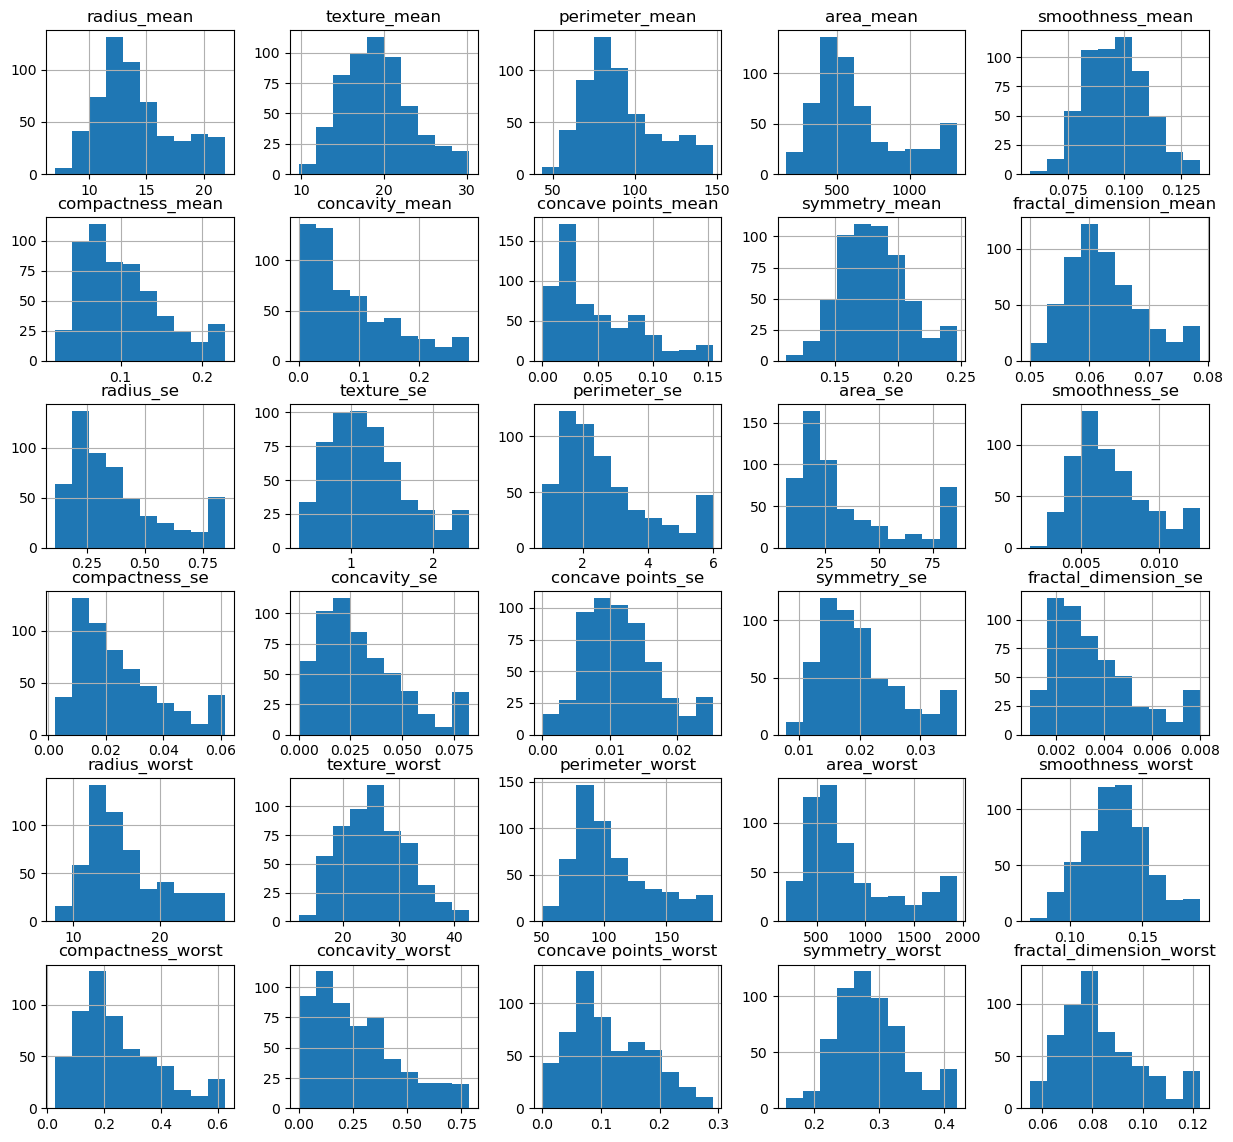

In [23]:
df.hist(figsize = (15,14))
plt.show()

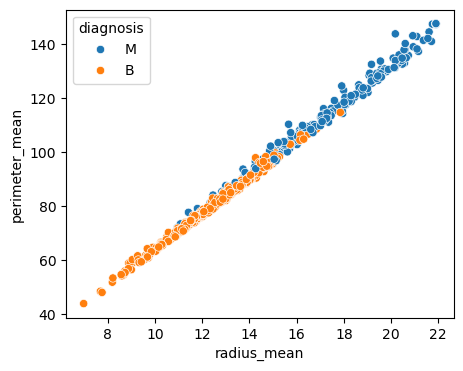

In [24]:
import matplotlib.pyplot as plt
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='radius_mean',
    y='perimeter_mean',
    hue='diagnosis',
    
)
plt.show()

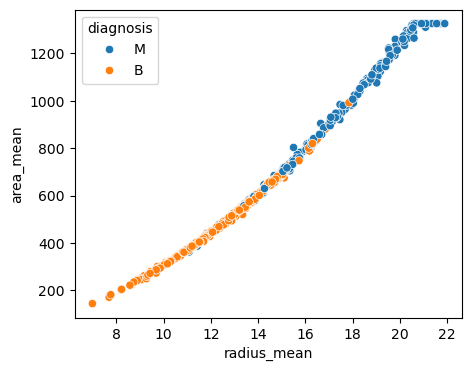

In [25]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='radius_mean',
    y='area_mean',
    hue='diagnosis',
)
plt.show()

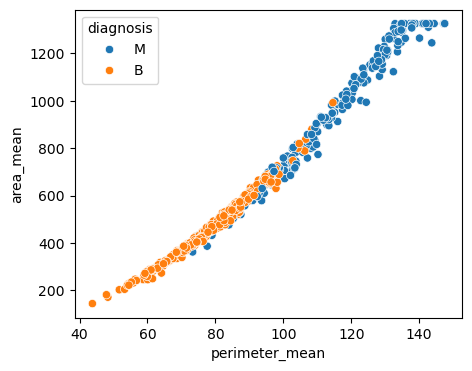

In [26]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='perimeter_mean',
    y='area_mean',
    hue='diagnosis',
)
plt.show()

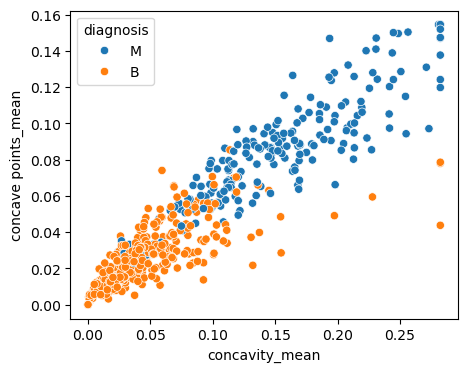

In [27]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='concavity_mean',
    y='concave points_mean',
    hue='diagnosis',
)
plt.show()

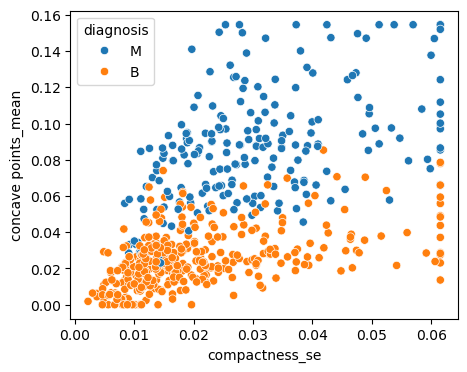

In [28]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='compactness_se',
    y='concave points_mean',
    hue='diagnosis',
)
plt.show()

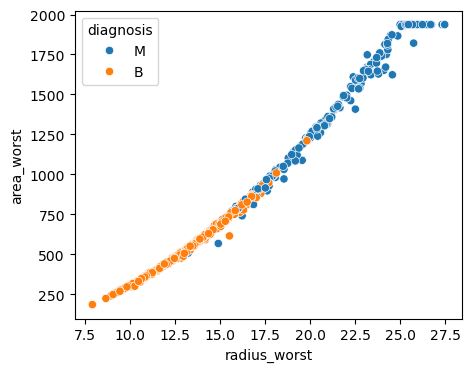

In [29]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='radius_worst',
    y='area_worst',
    hue='diagnosis',
)
plt.show()

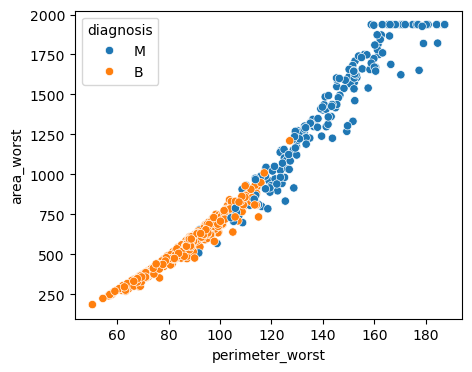

In [30]:
plt.figure(figsize=(5,4))

sns.scatterplot(
    data=df,
    x='perimeter_worst',
    y='area_worst',
    hue='diagnosis',
)
plt.show()

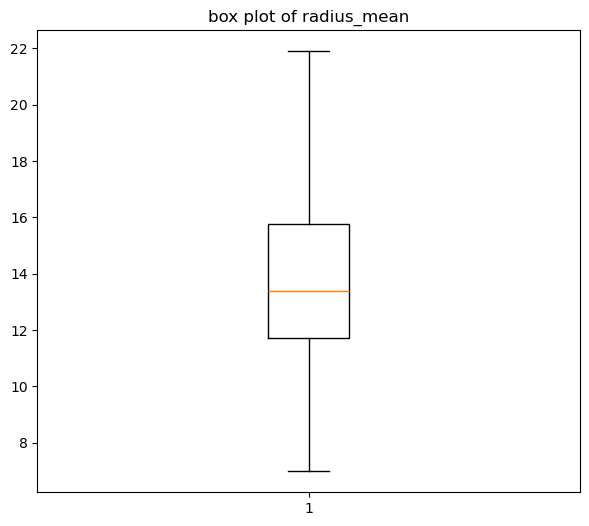

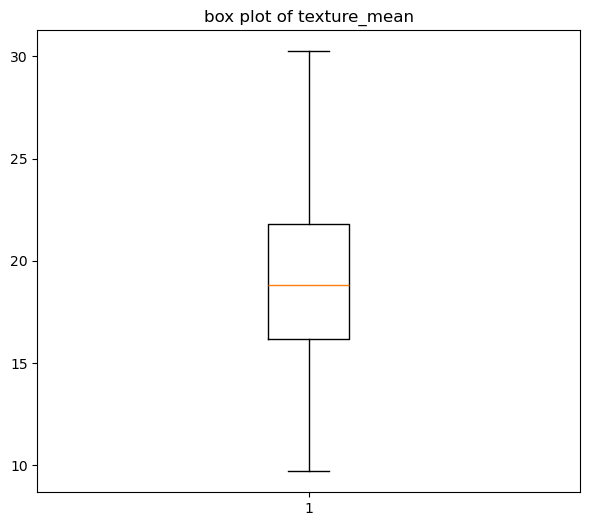

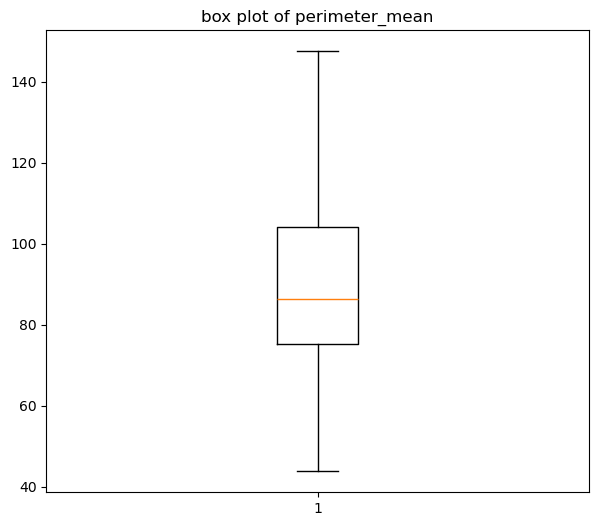

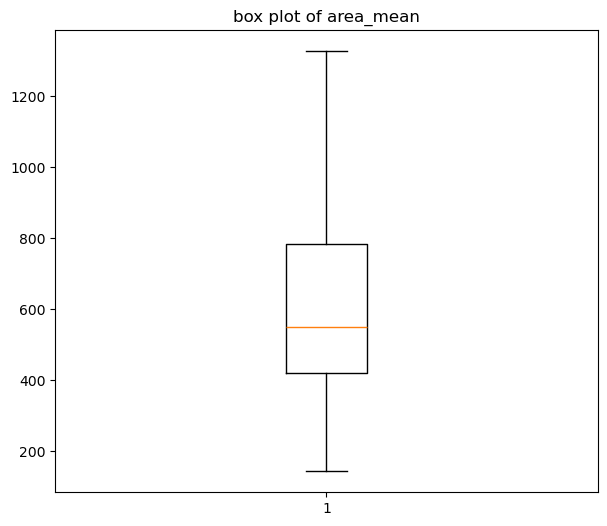

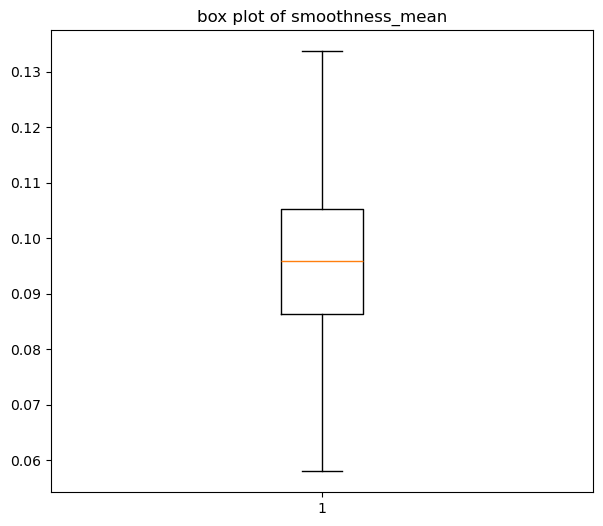

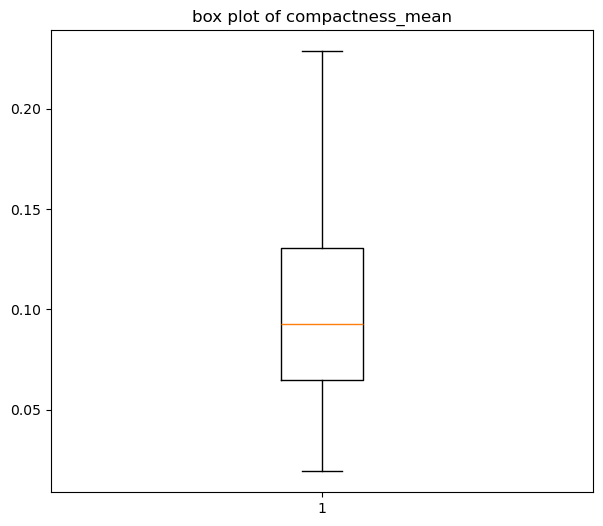

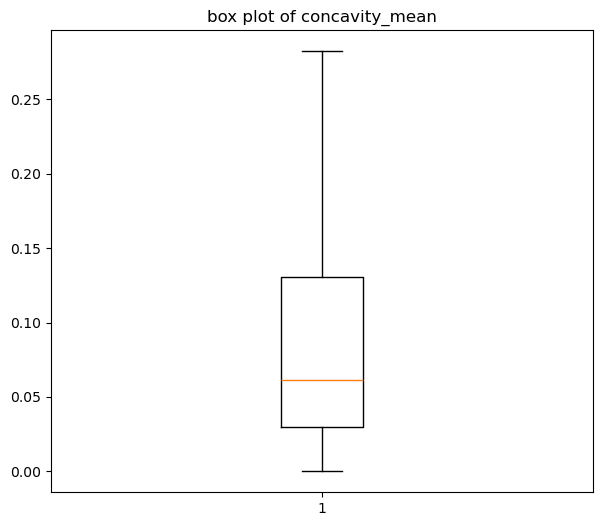

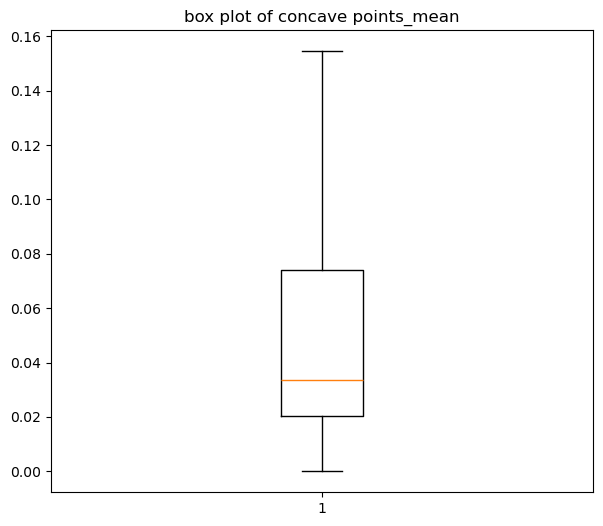

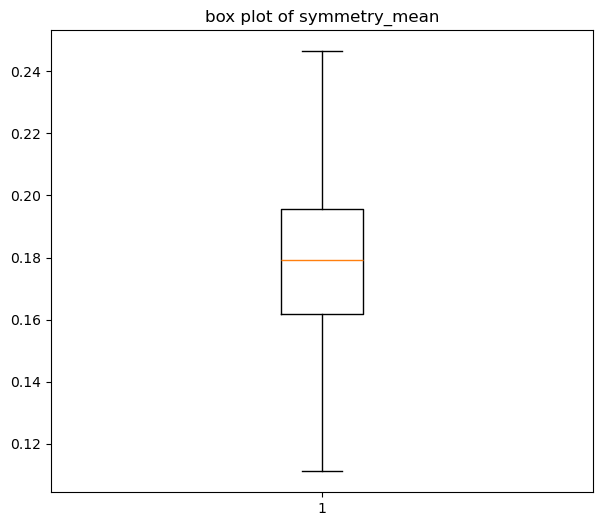

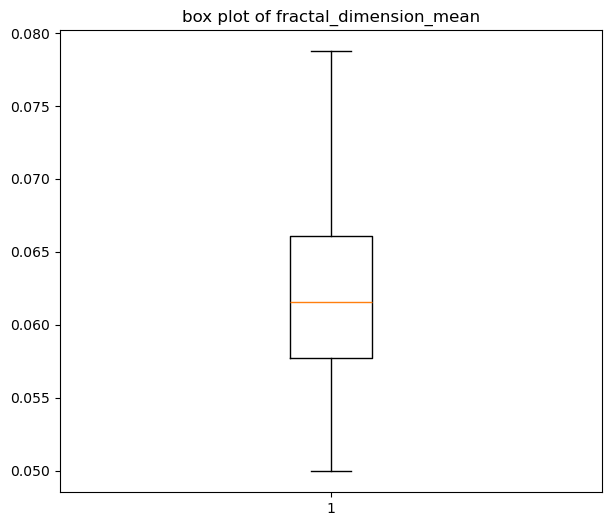

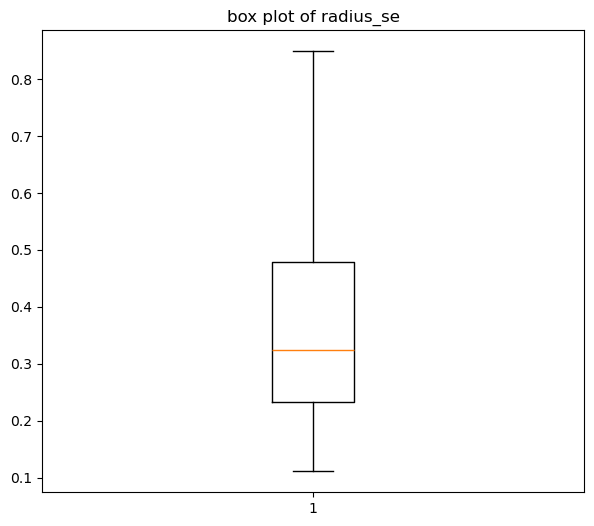

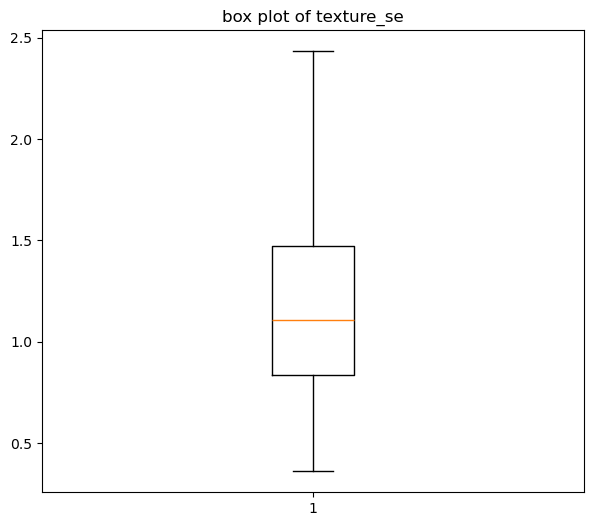

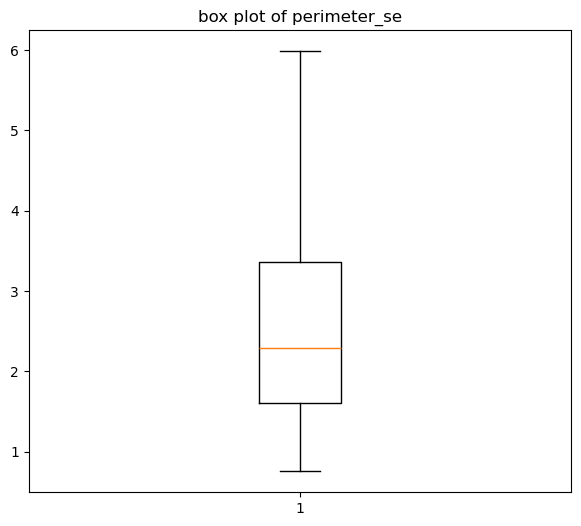

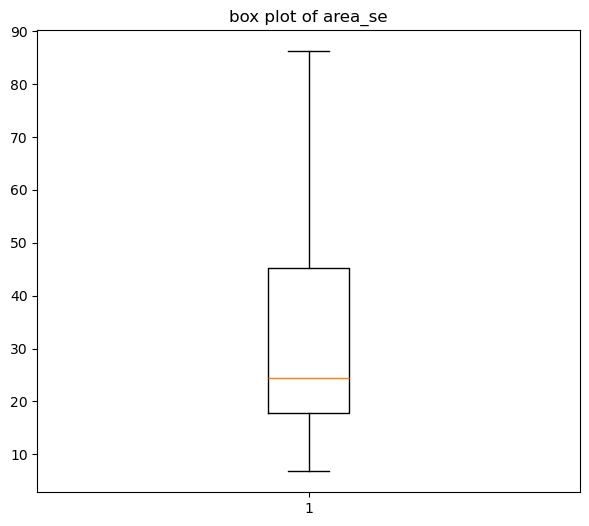

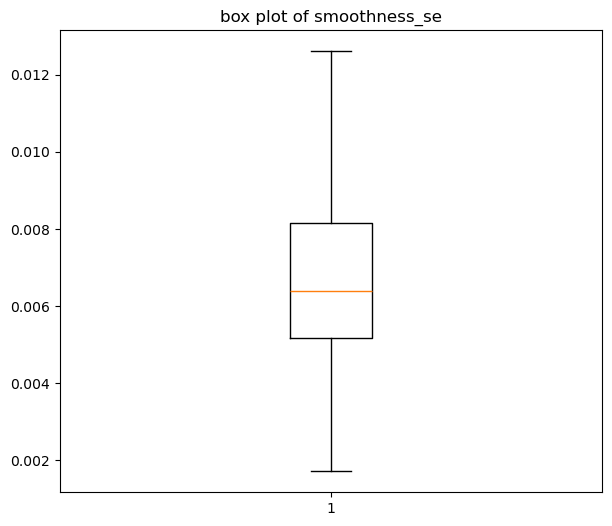

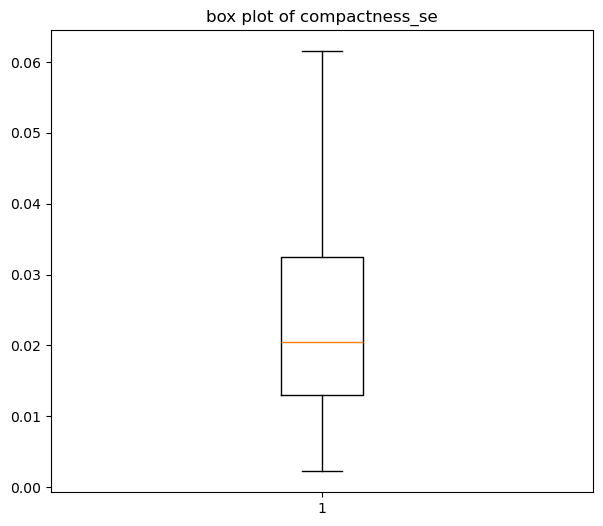

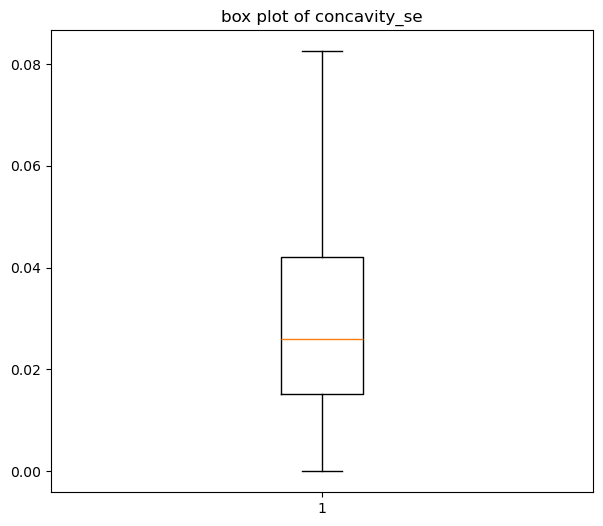

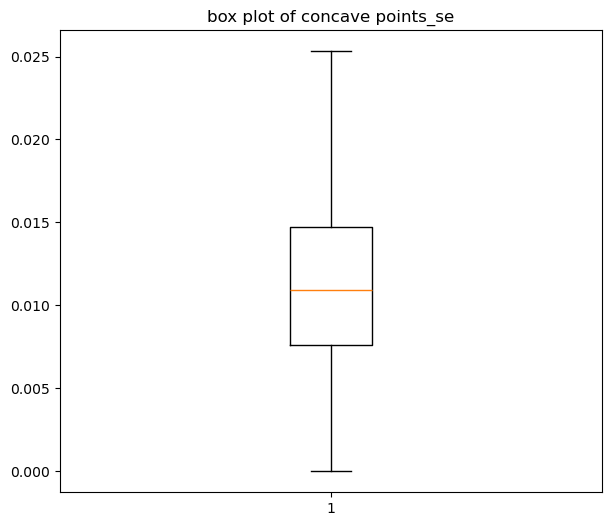

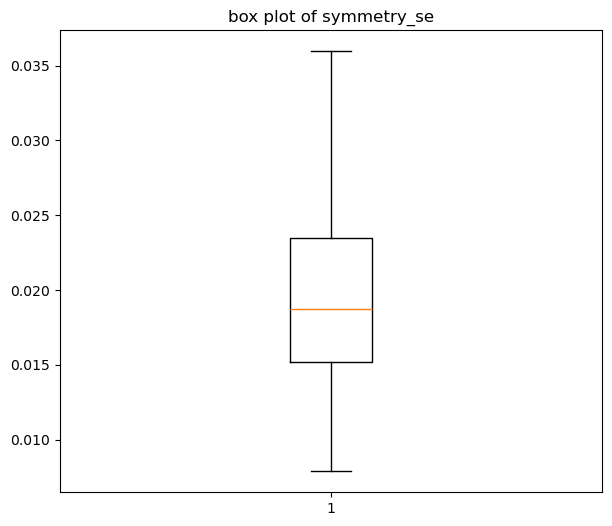

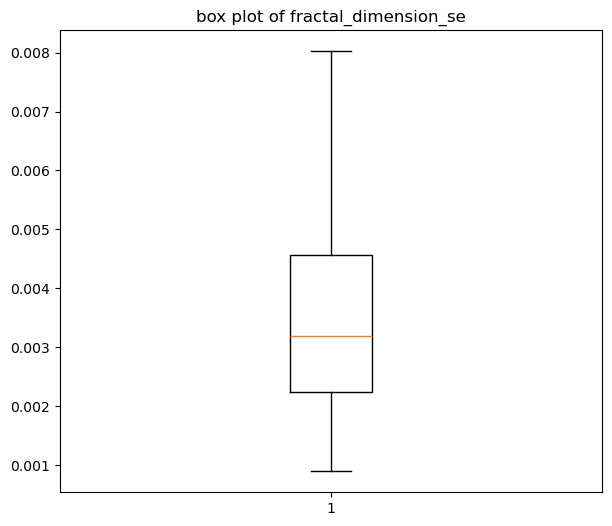

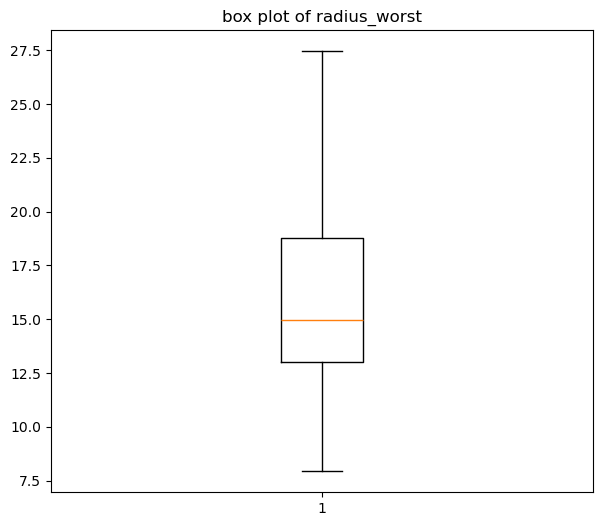

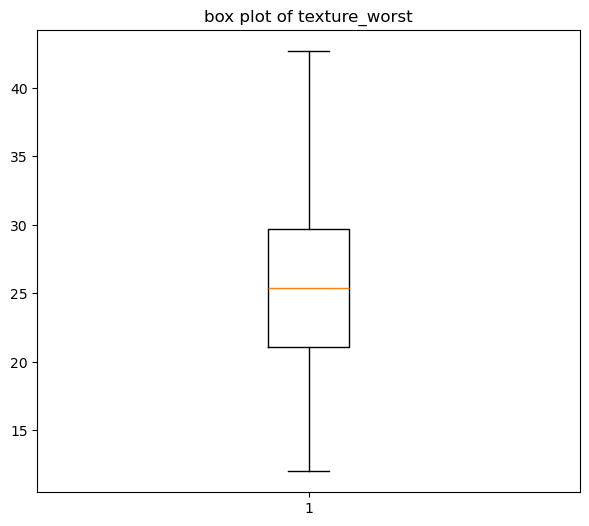

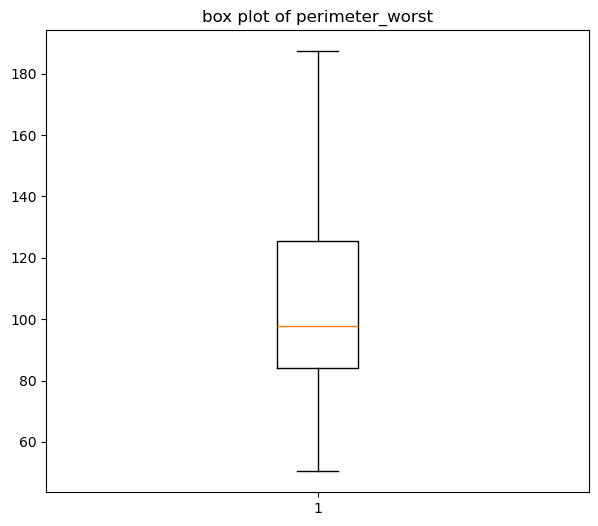

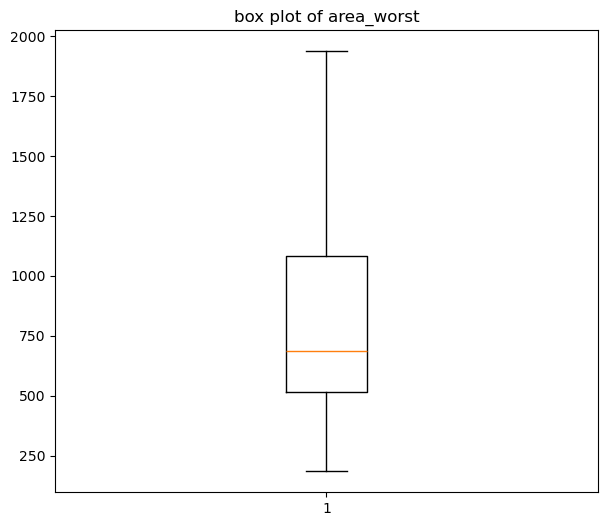

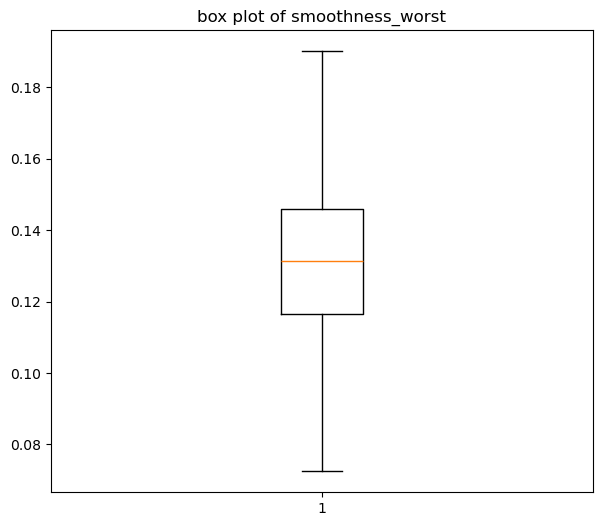

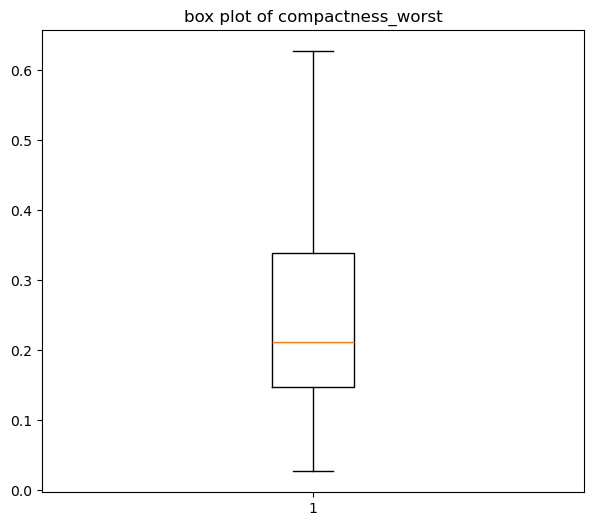

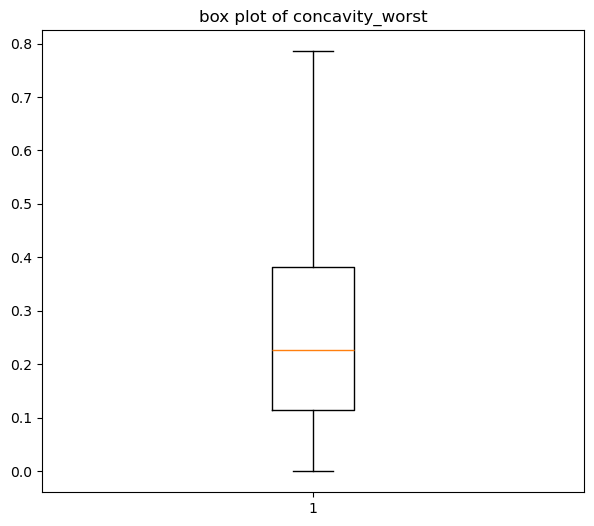

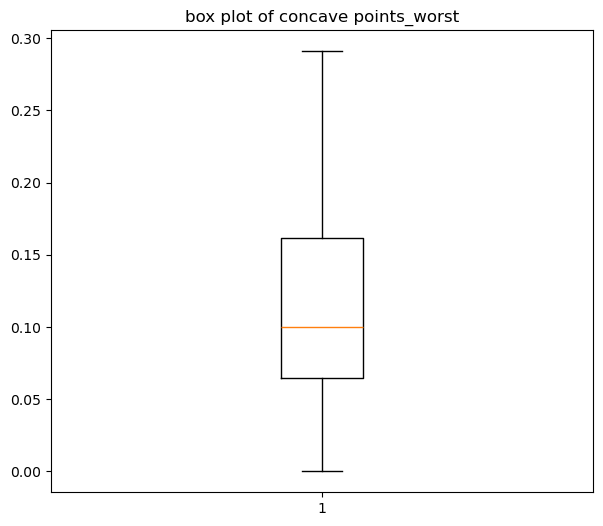

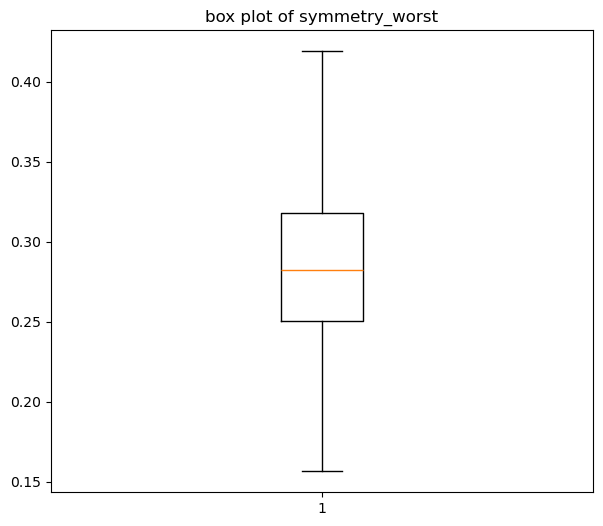

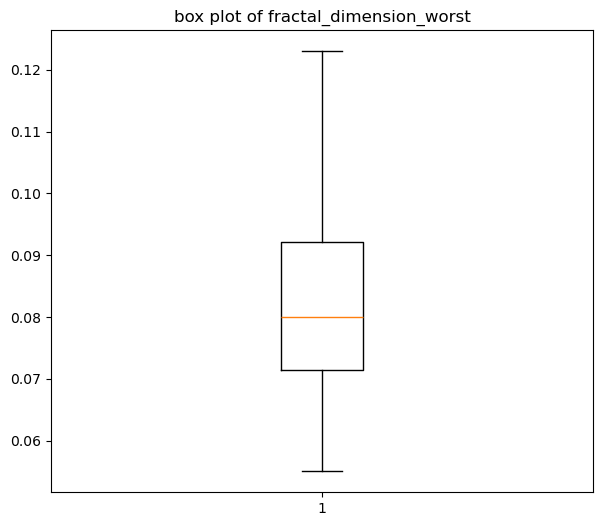

In [31]:
num_cols = df.select_dtypes(include='number').columns
for i in num_cols:
    plt.figure(figsize=(7,6))
    plt.title(f"box plot of {i}")
    plt.boxplot(df[i])
    plt.show()

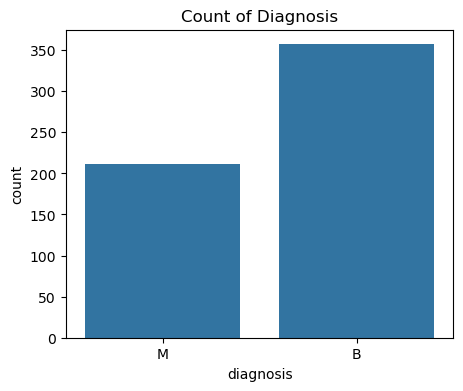

In [32]:
plt.figure(figsize=(5,4))
sns.countplot(data=df, x='diagnosis')
plt.title('Count of Diagnosis')
plt.show()

#### _The dataset has been successfully preprocessed, and the influence of outliers has been reduced._

## FEATURE SELECTION

#### _The categorical diagnosis variable is encoded into numerical values (M = 1, B = 0) to make it suitable for correlation analysis and machine learning algorithms._

In [33]:
df['diagnosis'].unique()

array(['M', 'B'], dtype=object)

In [34]:
df['diagnosis'] = df['diagnosis'].map({'M' :1, 'B' : 0})

In [35]:
df['diagnosis'].unique()

array([1, 0])

#### _A correlation matrix is generated to measure the relationship between numerical features and the target variable, helping identify the most relevant features for prediction._

In [36]:
df.corr()

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
diagnosis,1.000000,0.745217,0.419123,0.759006,0.752786,0.366931,0.608494,0.727168,0.788099,0.334536,...,0.793938,0.457663,0.800618,0.794640,0.423390,0.611083,0.683565,0.793566,0.419058,0.328719
radius_mean,0.745217,1.000000,0.332760,0.997692,0.993891,0.167672,0.502741,0.674539,0.811833,0.146763,...,0.973472,0.306225,0.967506,0.962549,0.126332,0.452062,0.559312,0.747817,0.187429,0.028799
texture_mean,0.419123,0.332760,1.000000,0.339588,0.341552,-0.015997,0.241666,0.318654,0.301509,0.079586,...,0.355583,0.911642,0.364127,0.357193,0.077224,0.276731,0.308860,0.296948,0.108611,0.113049
perimeter_mean,0.759006,0.997692,0.339588,1.000000,0.991861,0.204990,0.553698,0.714624,0.841871,0.181325,...,0.974555,0.312741,0.973889,0.963900,0.157912,0.496387,0.597326,0.776769,0.212299,0.075825
area_mean,0.752786,0.993891,0.341552,0.991861,1.000000,0.167400,0.498665,0.680126,0.814133,0.155152,...,0.973784,0.311537,0.967206,0.973460,0.133605,0.441642,0.556230,0.739618,0.185220,0.033012
smoothness_mean,0.366931,0.167672,-0.015997,0.204990,0.167400,1.000000,0.661938,0.526544,0.560961,0.557597,...,0.222464,0.044550,0.246572,0.222205,0.808981,0.482407,0.446253,0.510949,0.403159,0.504675
compactness_mean,0.608494,0.502741,0.241666,0.553698,0.498665,0.661938,1.000000,0.889882,0.832541,0.588842,...,0.542776,0.250386,0.593643,0.537159,0.570701,0.883162,0.835009,0.824531,0.496061,0.710169
concavity_mean,0.727168,0.674539,0.318654,0.714624,0.680126,0.526544,0.889882,1.000000,0.928382,0.489029,...,0.702115,0.316653,0.739514,0.703992,0.462648,0.795115,0.904529,0.881502,0.414279,0.546332
concave points_mean,0.788099,0.811833,0.301509,0.841871,0.814133,0.560961,0.832541,0.928382,1.000000,0.460386,...,0.832188,0.298107,0.855906,0.830127,0.460018,0.701609,0.781051,0.916542,0.384190,0.396626
symmetry_mean,0.334536,0.146763,0.079586,0.181325,0.155152,0.557597,0.588842,0.489029,0.460386,1.000000,...,0.191455,0.099704,0.222826,0.199919,0.431536,0.478419,0.441445,0.430649,0.707566,0.451494


## HEATMAP

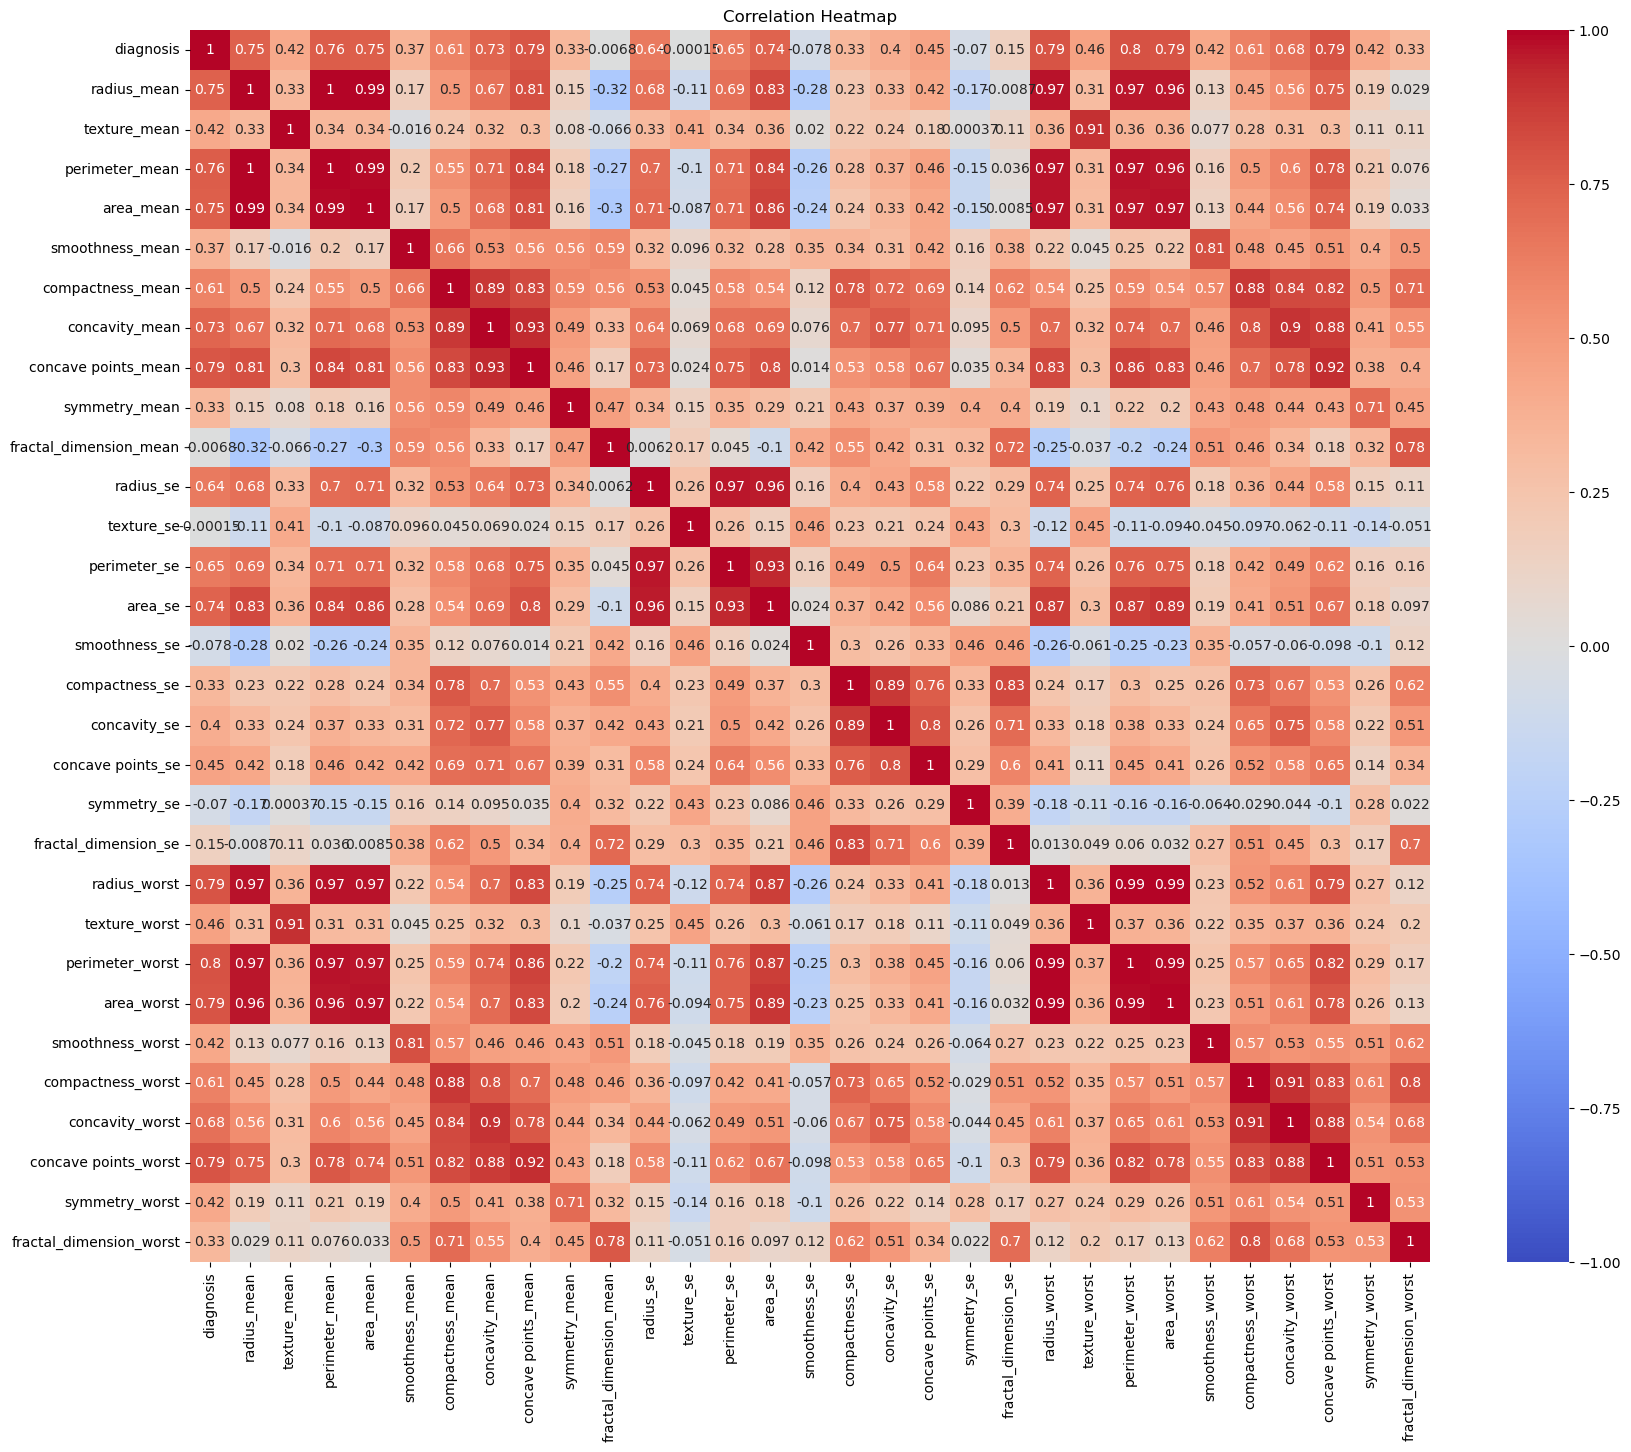

In [37]:
corr_matrix = df.corr()
plt.figure(figsize=(20,16))
sns.heatmap(corr_matrix, annot = True,cmap='coolwarm', vmin=-1, vmax=1)
plt.title('Correlation Heatmap')
plt.show()

The heatmap shows that several features have strong positive correlations, particularly radius, perimeter, area, and concavity-related features, indicating they are closely related.


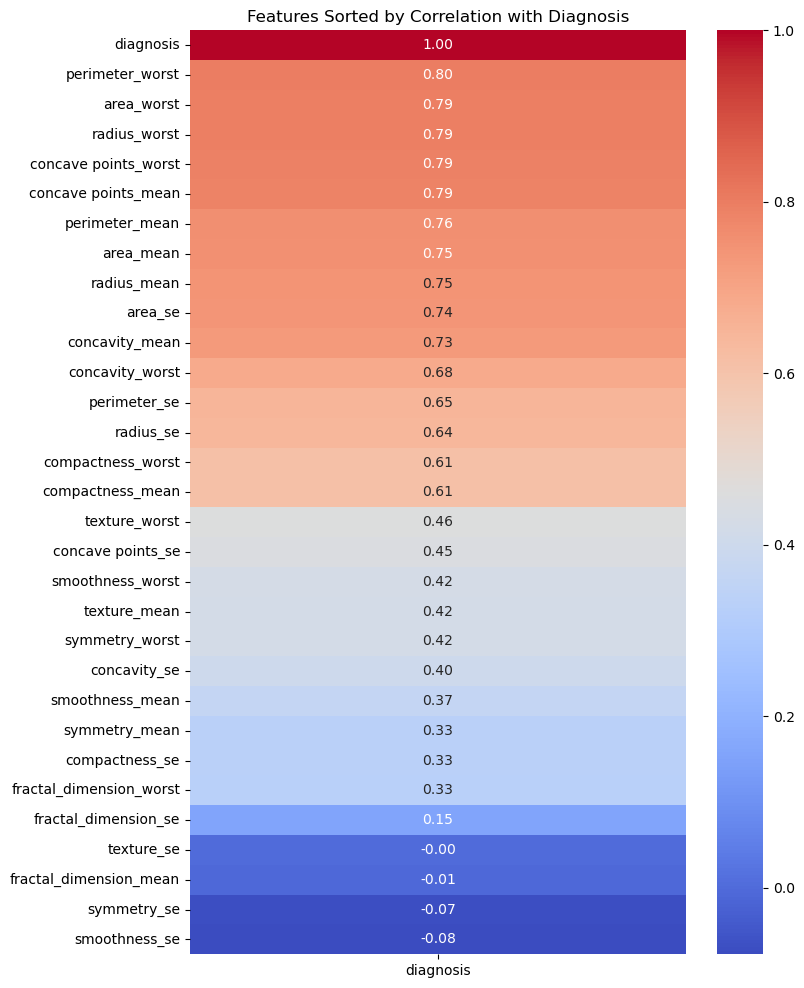

In [38]:

# Correlation with target
corr = df.corr(numeric_only=True)

# Sort by diagnosis correlation
sorted_corr = corr.sort_values(by='diagnosis', ascending=False)

plt.figure(figsize=(8,12))

sns.heatmap(
    sorted_corr[['diagnosis']],
    annot=True,
    cmap='coolwarm',
    fmt='.2f'
)

plt.title('Features Sorted by Correlation with Diagnosis')
plt.show()

#### The selected features are assigned to X (independent variables), and the diagnosis column is assigned to y (target variable)

In [39]:
X = df[['perimeter_worst','area_worst','radius_worst','concave points_worst','concave points_mean','perimeter_mean','area_mean','radius_mean','area_se','concavity_mean','concavity_worst','perimeter_se','radius_se','compactness_worst','compactness_mean']]
y = df['diagnosis']

In [40]:
X.columns

Index(['perimeter_worst', 'area_worst', 'radius_worst', 'concave points_worst',
       'concave points_mean', 'perimeter_mean', 'area_mean', 'radius_mean',
       'area_se', 'concavity_mean', 'concavity_worst', 'perimeter_se',
       'radius_se', 'compactness_worst', 'compactness_mean'],
      dtype='object')

In [41]:
X.shape

(569, 15)

## DATA TRANSFORMATION

### __STANDARD SCALER__

#### _StandardScaler is used to standardize numerical features to a common scale for better model performance._

In [42]:
#FOR NUMERIC
SS=StandardScaler()
SS_X=SS.fit_transform(X)
SS_X=pd.DataFrame(SS_X)
SS_X.columns=['perimeter_worst','area_worst','radius_worst','concave points_worst','concave points_mean','perimeter_mean','area_mean','radius_mean','area_se','concavity_mean','concavity_worst','perimeter_se','radius_se','compactness_worst','compactness_mean']
SS_X.head()

,perimeter_worst,area_worst,radius_worst,concave points_worst,concave points_mean,perimeter_mean,area_mean,radius_mean,area_se,concavity_mean,concavity_worst,perimeter_se,radius_se,compactness_worst,compactness_mean
0,2.439568,2.287627,2.006477,2.296076,2.620973,1.357375,1.184085,1.176800,2.110995,2.647422,2.246192,2.343091,2.280613,2.641905,2.541404
1,1.631542,2.287627,1.921384,1.087084,0.574944,1.795991,2.249396,1.949929,1.611678,-0.000497,-0.137634,0.498609,0.780609,-0.443388,-0.498189
2,1.434234,1.807751,1.611558,1.955000,2.110330,1.670052,1.846217,1.686226,2.110995,1.496076,0.920718,1.345409,1.774057,1.223448,1.148680
3,-0.245395,-0.593838,-0.277945,2.175786,1.506601,-0.606410,-0.831485,-0.791983,-0.318438,2.091997,2.119474,0.532139,0.545151,2.641905,2.541404
4,1.424838,1.525780,1.386825,0.729259,1.482665,1.891531,2.154338,1.866023,2.110995,1.504202,0.665254,1.953934,1.831079,-0.314469,0.599453


## DATA PARTITION

In [43]:
X_train, X_test, Y_train, Y_test = train_test_split(SS_X, y, test_size=0.3, random_state=42, stratify=y)

#### _The dataset is split into training (70%) and testing (30%) sets to train the model and evaluate its performance on unseen data. Specifically, out of the total 569 rows, 398 rows are allocated for training and 171 rows are kept for testing._

### MODEL SELECTION

In [44]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression()

### FIT THE MODEL

In [45]:
model.fit(X_train, Y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


### PREDICT THE MODEL

In [46]:
Y_pred_train = model.predict(X_train)
Y_pred_test = model.predict(X_test)

## MODEL EVALUALUATION

In [47]:
train_accuracy = accuracy_score(Y_train,Y_pred_train)
test_accuracy = accuracy_score(Y_test,Y_pred_test)

train_precision = precision_score(Y_train,Y_pred_train)
test_precision = precision_score(Y_test,Y_pred_test)

train_recall = recall_score(Y_train,Y_pred_train)
test_recall = recall_score(Y_test,Y_pred_test)

train_f1 = f1_score(Y_train,Y_pred_train)
test_f1 = f1_score(Y_test,Y_pred_test)

In [48]:
print("Training Accuracy :", np.round(train_accuracy,2))
print("Testing Accuracy  :", np.round(test_accuracy,2))

print()

print("Training Precision :", np.round(train_precision,2))
print("Testing Precision  :", np.round(test_precision,2))

print()

print("Training Recall :", np.round(train_recall,2))
print("Testing Recall  :", np.round(test_recall,2))

print()

print("Training F1 Score :", np.round(train_f1,2))
print("Testing F1 Score  :", np.round(test_f1,2))

Training Accuracy : 0.95
Testing Accuracy  : 0.98

Training Precision : 0.96
Testing Precision  : 1.0

Training Recall : 0.91
Testing Recall  : 0.94

Training F1 Score : 0.93
Testing F1 Score  : 0.97


In [49]:
train_score = model.score(X_train,Y_train)

test_score = model.score(X_test,Y_test)

print("Train Score:",np.round(train_score,2))
print("Test Score:",np.round(test_score,2))

Train Score: 0.95
Test Score: 0.98


### CROSS VALIDATION

In [50]:
from sklearn.model_selection import cross_val_score

# 5-Fold Cross Validation

cv_scores=cross_val_score(model,SS_X,y,cv=5)
print('cross validation score: ',cv_scores)
print('cross validation mean score: ',cv_scores.mean())

cross validation score:  [0.9122807  0.93859649 0.96491228 0.96491228 0.96460177]
cross validation mean score:  0.9490607048594939


#### _The high cross-validation accuracy indicates that the model is consistent and generalizes well to unseen data._

In [51]:
print("Training Accuracy :", np.round(train_accuracy,2))
print("Testing Accuracy  :", np.round(test_accuracy,2))
print("Mean CV Accuracy:", np.round(cv_scores.mean(),2))

Training Accuracy : 0.95
Testing Accuracy  : 0.98
Mean CV Accuracy: 0.95


In [52]:
cm = confusion_matrix(Y_test, Y_pred_test)
print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[107   0]
 [  4  60]]


## CONFUSION MATRIX

In [59]:
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

NameError: name 'final_model' is not defined

In [54]:
# classification Report

print(classification_report (Y_test,Y_pred_test, target_names = ['Benign', 'Malignant']))

              precision    recall  f1-score   support

      Benign       0.96      1.00      0.98       107
   Malignant       1.00      0.94      0.97        64

    accuracy                           0.98       171
   macro avg       0.98      0.97      0.97       171
weighted avg       0.98      0.98      0.98       171



##  ROC Curve and AUC Score

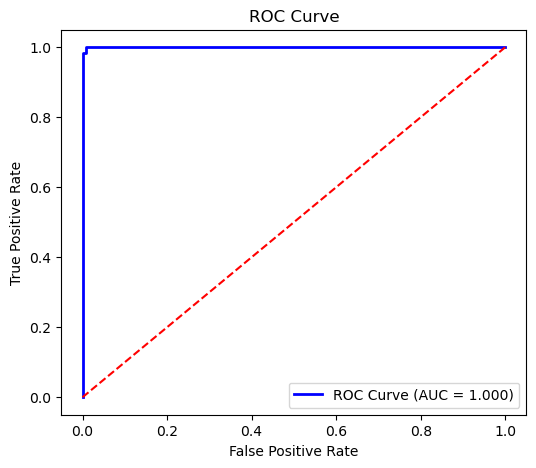

AUC Score: 0.9998539719626168


In [55]:
# ROC Curve and AUC Score

from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# Get prediction probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# Calculate ROC Curve
fpr, tpr, thresholds = roc_curve(Y_test, y_prob)

# Calculate AUC Score
auc_score = roc_auc_score(Y_test, y_prob)

# Plot ROC Curve
plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, color='blue', linewidth=2,
         label='ROC Curve (AUC = %0.3f)' % auc_score)

plt.plot([0,1], [0,1], color='red', linestyle='--')

plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')

plt.show()

print("AUC Score:", auc_score)

#### _The ROC curve is close to the top-left corner, and the high AUC score indicates excellent classification performance._

### PREDICTING VALUES

In [56]:
import pandas as pd

# New input
new_data = pd.DataFrame({
    'perimeter_worst': [110.5],
    'area_worst': [900.2],
    'radius_worst': [18.5],
    'concave points_worst': [0.18],
    'concave points_mean': [0.10],
    'perimeter_mean': [90.4],
    'area_mean': [650.8],
    'radius_mean': [14.8],
    'area_se': [45.2],
    'concavity_mean': [0.15],
    'concavity_worst': [0.30],
    'perimeter_se': [3.2],
    'radius_se': [0.85],
    'compactness_worst': [0.28],
    'compactness_mean': [0.12]
})

# Use the ORIGINAL scaler (SS) that was fit on raw X earlier in the notebook.
# Do NOT create a new StandardScaler here.
new_data_scaled = SS.transform(new_data)

# Predict
prediction = model.predict(new_data_scaled)

print("Predicted Class:", prediction[0])

if prediction[0] == 1:
    print("Prediction: Malignant")
else:
    print("Prediction: Benign")

Predicted Class: 1
Prediction: Malignant


## SAVE THE MODEL

In [58]:
# Train the model
model.fit(X_train, Y_train)

import pickle

# Save the trained model
with open("model.pkl", "wb") as file:
    pickle.dump(model, file)

# Save the StandardScaler
with open("scaler.pkl", "wb") as file:
    pickle.dump(SS, file)

# Save the selected feature names
feature_names = X.columns.tolist()

with open("features.pkl", "wb") as file:
    pickle.dump(feature_names, file)

print("Model, Scaler, and Feature Names saved successfully!")

Model, Scaler, and Feature Names saved successfully!
